<div style="background-color: #367E7F; color: white ; padding: 10px; font-size: 24px; border-radius: 5px; text-align: center;">
    Object classification (player, goalkeeper, referee) in football using deep learning models, based on the V.League 2024–2025 image dataset
</div>
<div style=" color: #595959; padding: 10px; font-size: 16px; border-radius: 5px; text-align: center;">
    A Comprehensive Analysis and Detection of Objects using Image Classification Technology
</div>

<div style="color: #595959; padding: 15px; font-size: 16px; border: 1px solid #367E7F; border-radius: 6px">
    <h3>🔹 Football Image Classification 🖼️✨</h3>
    <p>Phân loại đối tượng (Cầu thủ, Thủ môn, Trọng tài) trong bóng đá bằng mô hình học sâu, sử dụng tập hình ảnh V.League 2024-25.</p>
    <p>Bài toán này là một kỹ thuật trong lĩnh vực Football Analytics, với mục tiêu phân tích video theo yêu cầu (on-demand), video livestream hoặc video ghi hình từ thiết bị chuyên dụng. Dữ liệu hình ảnh sau đó được xử lý để nhận diện và tính toán các thông số kỹ thuật của từng cầu thủ và từng đội bóng, phục vụ cho các mục đích như thống kê, chiến thuật, và phân tích hiệu suất thi đấu.</p>
</div>

<h2 style="background-color: #367E7F; color: white; padding: 15px; text-align: center; font-size: 20px; border-radius: 6px; font-weight: bold;">
    1. Import Necessary Libraries
</h2>

In [1]:
import os #Quản lý thư mục, tập tin, đường dẫn tập tin
import pandas as pd #Thao tác trên dữ liệu dạng bảng (dataframe, csv,...)
import numpy as np #Xử lý dữ liệu số, dữ liệu mảng
import matplotlib.pyplot as plt #Vẽ biểu đồ
import seaborn as sns #Vẽ biểu đồ
from sklearn.model_selection import train_test_split #Chia dữ liệu
from sklearn.metrics import confusion_matrix #Đánh giá mô hình phân loại, số lượng dự đoán đúng và sai
import tensorflow as tf #Thư viện mã nguồn mở của Google dành cho deep learning
from tensorflow import keras #APIs của tensorflow để xây dựng mạng CNN
from tensorflow.keras.layers import Dense, Conv2D, MaxPooling2D, Flatten, Dropout
#Dense: lớp kết nối đầy đủ (fully connected layer) trong mạng CNN
#Conv2D: lớp tích chập dùng trong mạng CNN để xử lý ảnh
#Maxpooling2D: Lớp pooling giúp giảm kích thước của ảnh, giảm overfiting
#Flatten: Chuyển đổi tensor nhiều chiều thành vector 1 chiều.
#Dropout: Lớp giảm overfitting bằng cách loại bỏ ngẫu nhiên một số neuron trong quá trình huấn luyện
from tensorflow.keras.models import Sequential #Mô hình mạng tuần tự trong Keras
from tensorflow.keras.optimizers import Adamax #Thuật toán tối ưu Adam dùng trong huấn luyện mô hình
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau #Giúp dừng huấn luyện sớm nếu mô hình không cải thiện sau một số epoch nhất định
from tensorflow.keras.layers import BatchNormalization, GlobalAveragePooling2D #Chuẩn hóa đầu ra của mỗi lớp để tăng tốc huấn luyện
from tqdm import tqdm #Hiển thị thanh tiến trình khi chạy vòng lặp
from tensorflow.keras.preprocessing.image import ImageDataGenerator #Tăng cường dữ liệu ảnh: xoay, lật, thay đổi độ sáng...
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.models import load_model
from PIL import Image
import random
import warnings
warnings.filterwarnings('ignore')

2025-04-26 14:12:16.897995: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1745676737.080553      31 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1745676737.134668      31 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


<h2 style="background-color: #367E7F; color: white; padding: 15px; text-align: center; font-size: 20px; border-radius: 6px; font-weight: bold;">
    2. Setting hyperparameters for model training  
</h2>

<div style="color: #595959; padding: 15px; font-size: 16px; border: 1px solid #367E7F; border-radius: 6px">
    <p>Epoch: Là một lần duyệt toàn bộ tập dữ liệu của mô hình</p>
    <p>Ví dụ: Tập dữ liệu có 10.000 ảnh</p>
    <p>epoch = 1: Mô hình duyệt qua 10.000 ảnh đúng 1 lần</p>
    <p>epoch = 10: mô hình duyệt qua 10.000 ảnh 10 lần</p>
    <p>Epoch quá nhỏ mô hình có thể chưa học đủ dễ dẫn đến underfiting</p>
    <p>Epoch quá lớn: mô hình có thể học quá kỹ dữ liệu huấn luyện dễ dẫn đến overfiting</p>
    <p>Có thể dùng EarlyStopping để ngăn mô hình học quá mức</p>
</div>

In [2]:
BATCH_SIZE = 32 # Số lượng mẫu dữ liệu được đưa vào mô hình trong một lần cập nhật trọng số
IMAGE_SIZE = (224,224)
# BATCH_SIZE có thể cần điều chỉnh dựa trên bộ dữ liệu và tài nguyên phần cứng
#   BATCH_SIZE = 32 giúp cân bằng giữa tốc độ huấn luyện và ổn định của gradient
#   Nếu tập dữ liệu quá nhỏ, có thể thử BATCH_SIZE = 16 hoặc 8 để xem có cải thiện không
#   Nếu dùng GPU với bộ nhớ hạn chế, batch nhỏ hơn có thể giúp tránh lỗi out of memory
# IMAGE_SIZE = (224,224) phù hợp với nhiều kiến trúc CNN phổ biến
#   Nếu ảnh gốc có kích thước lớn hơn, việc resize về 224x224 có thể làm mất chi tiết quan trọng
#   Có thể thử 256x256 hoặc 299x299 (nếu mô hình hỗ trợ) để xem có cải thiện không

<h2 style="background-color: #367E7F; color: white; padding: 15px; text-align: center; font-size: 20px; border-radius: 6px; font-weight: bold;">
    3. Data Preparation
</h2>

In [3]:
# train_dir: thư mục chứa ảnh để huấn luyện mô hình
# test_dir: chứa ảnh để đánh giá mô hình sau khi huấn luyện (kiểm tra độ chính xác)
# pred_dir: dùng để lưu hoặc chứa ảnh cần dự đoán (inference) sau khi mô hình đã được huấn luyện
train_dir = '/kaggle/input/vleague-lpbank-24-25-v6/train'
pred_dir = '/kaggle/input/vleague-lpbank-24-25-v6/pred'
test_dir = '/kaggle/input/vleague-lpbank-24-25-v6/test'

<h2 style="background-color: #367E7F; color: white; padding: 15px; text-align: center; font-size: 20px; border-radius: 6px; font-weight: bold;">
    3.1 Preparing training data: collecting file paths and corresponding labels
</h2>

In [4]:
# Duyệt qua các thư mục con trong train_dir, thu thập đường dẫn của các tệp trong các thư mục con, sau đó gán nhãn cho chúng dựa trên tên thư mục
filepaths_train= [] # Lưu danh sách các đường dẫn đầy đủ của các tệp trong train_dir
label_train = [] # Lưu nhãn tương ứng với mỗi tệp (dựa vào thư mục chứa tệp đó)
folds = os.listdir(train_dir)
for fold in folds: # Duyệt qua từng thư mục con trong train_dir
    foldpath = os.path.join(train_dir,fold)
    files = os.listdir(foldpath)
    for file in tqdm(files): # Lặp qua từng tệp trong thư mục con, tqdm(files) được sử dụng để hiển thị thanh tiến trình khi duyệt
        filepath = os.path.join(foldpath,file)
        filepaths_train.append(filepath)
        label_train.append(fold)

# Shuffle dữ liệu
#combined = list(zip(filepaths_train, label_train))
#random.shuffle(combined)
#filepaths_train, label_train = zip(*combined)

100%|██████████| 800/800 [00:00<00:00, 826463.84it/s]


In [5]:
# Số lượng đường dẫn tệp đã được thu thập (~ số lượng tệp của tập train)
print(f"Number of train filepaths: {len(filepaths_train)}")

Number of train filepaths: 2385


In [6]:
# Hiển thị 5 phần tử đầu tiên của 2 danh sách filepaths_train và label_trains
print(filepaths_train[:5])
label_train[:5]

['/kaggle/input/vleague-lpbank-24-25-v6/train/goalkeeper/112.QNFVHAGL7_f0340_p00.jpg', '/kaggle/input/vleague-lpbank-24-25-v6/train/goalkeeper/98.ĐATHVHP7_f0482_p02.jpg', '/kaggle/input/vleague-lpbank-24-25-v6/train/goalkeeper/8.TVHNF7_f0377_p00.jpg', '/kaggle/input/vleague-lpbank-24-25-v6/train/goalkeeper/4.CAHNVTXNĐ7_f0677_p02.jpg', '/kaggle/input/vleague-lpbank-24-25-v6/train/goalkeeper/32.QNVBBD7_f0337_p00.jpg']


['goalkeeper', 'goalkeeper', 'goalkeeper', 'goalkeeper', 'goalkeeper']

<div style="background-color: #367E7F; color: white; padding: 15px; text-align: center; font-size: 20px; border-radius: 6px; font-weight: bold;">
    Creating a DataFrame to organize training data and analysis
</div>

In [7]:
# Tạo một DataFrame từ danh sách filepaths_train và label_train
df_train = pd.DataFrame({'filepath_train': filepaths_train, 'label_train': label_train})

In [8]:
# Xem 5 dòng đầu tiên
df_train.head()

,filepath_train,label_train
0,/kaggle/input/vleague-lpbank-24-25-v6/train/go...,goalkeeper
1,/kaggle/input/vleague-lpbank-24-25-v6/train/go...,goalkeeper
2,/kaggle/input/vleague-lpbank-24-25-v6/train/go...,goalkeeper
3,/kaggle/input/vleague-lpbank-24-25-v6/train/go...,goalkeeper
4,/kaggle/input/vleague-lpbank-24-25-v6/train/go...,goalkeeper


<h2 style="background-color: #367E7F; color: white; padding: 15px; text-align: center; font-size: 20px; border-radius: 6px; font-weight: bold;">
    3.2 Visualizing the distribution of training data across different classes
</h2>

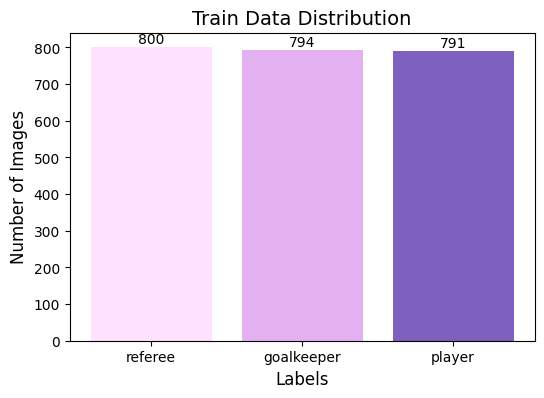

In [9]:
# Tạo biểu đồ cột (bar chart) để hiển thị phân phối số lượng mẫu theo từng nhãn (label_train) trong tập dữ liệu df_train
# Màu sắc tùy chỉnh
color = ['#FFE1FF', '#E4B1F0', '#7E60BF', '#433878']
# Đếm số lượng mẫu của mỗi nhãn
label_counts = df_train['label_train'].value_counts()
# Vẽ biểu đồ
plt.figure(figsize=(6,4))
plt.bar(label_counts.index, label_counts.values, color = color)
# Thêm tiêu đề và nhãn của các trục
plt.title('Train Data Distribution', fontsize=14)
plt.xlabel('Labels', fontsize=12)
plt.ylabel('Number of Images', fontsize=12)
# Hiển thị giá trị trên từng cột
for i, v in enumerate(label_counts.values):
    plt.text(i, v + 10, f"{v:,}", ha='center', fontsize=10)
# Hiển thị biểu đồ
plt.show()

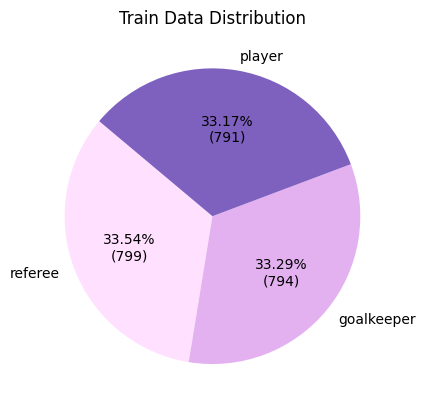

In [10]:
# Tạo biểu đồ tròn (pie chart) để hiển thị phân phối số lượng mẫu theo từng nhãn (label_train) trong tập dữ liệu df_train
# Đếm số lượng mẫu của mỗi nhãn
label_counts = df_train['label_train'].value_counts()
# Vẽ biểu đồ tròn
plt.pie(label_counts, 
        labels=label_counts.index, 
        colors = color, 
        autopct=lambda p: f'{p:.2f}%\n({int(p * label_counts.sum() / 100):,})', # Hiển thị cả số lượng mẫu
        startangle=140 # Xoay biểu đồ để có góc nhìn đẹp hơn
       )
# Thêm tiêu đề
plt.title('Train Data Distribution')
# Hiển thị biểu đồ
plt.show()

In [11]:
# Hiển thị số lượng mẫu của từng nhãn trong cột label_train (theo thứ tự giảm dần)
print(df_train['label_train'].value_counts().apply(lambda x: f"{x:,}"))

label_train
referee       800
goalkeeper    794
player        791
Name: count, dtype: object


In [12]:
# Hiển thị số lượng dòng (rows) và cột (columns) của DataFrame df_train
print(f'This train data has {df_train.shape[0]:,} rows and {df_train.shape[1]:,} columns')

This train data has 2,385 rows and 2 columns


<h2 style="background-color: #367E7F; color: white; padding: 15px; text-align: center; font-size: 20px; border-radius: 6px; font-weight: bold;">
    3.3 Preparing test data: collecting file paths and corresponding labels
</h2>

In [13]:
# Duyệt qua các thư mục con trong test_dir, thu thập đường dẫn của các tệp trong các thư mục con, sau đó gán nhãn cho chúng dựa trên tên thư mục
filepaths_test= [] # Lưu danh sách các đường dẫn đầy đủ của các tệp trong test_dir
label_test = []
folds = os.listdir(test_dir)
for fold in folds: # Lưu nhãn tương ứng với mỗi tệp (dựa vào thư mục chứa tệp đó)
    foldpath = os.path.join(test_dir,fold)
    files = os.listdir(foldpath)
    for file in tqdm(files): # Lặp qua từng tệp trong thư mục con, tqdm(files) được sử dụng để hiển thị thanh tiến trình khi duyệt
        filepath = os.path.join(foldpath,file)
        filepaths_test.append(filepath)
        label_test.append(fold)

100%|██████████| 198/198 [00:00<00:00, 235394.61it/s]


In [14]:
# Số lượng đường dẫn tệp đã được thu thập (~ số lượng tệp của tập train)
print(f"Number of test filepaths: {len(filepaths_test)}")

Number of test filepaths: 601


In [15]:
# Hiển thị 5 phần tử đầu tiên của 2 danh sách filepaths_test và label_test
print(filepaths_test[:5])
label_test[:5]

['/kaggle/input/vleague-lpbank-24-25-v6/test/goalkeeper/55.QNBĐVHP7_f0056_p00.jpg', '/kaggle/input/vleague-lpbank-24-25-v6/test/goalkeeper/39.HLHTVHP7_f0366_p00.jpg', '/kaggle/input/vleague-lpbank-24-25-v6/test/goalkeeper/11.SLNAVCAHN7_f0438_p01.jpg', '/kaggle/input/vleague-lpbank-24-25-v6/test/goalkeeper/44.ĐATHVSĐN7_f0336_p00.jpg', '/kaggle/input/vleague-lpbank-24-25-v6/test/goalkeeper/84.HPVTXNĐ7_f0499_p00.jpg']


['goalkeeper', 'goalkeeper', 'goalkeeper', 'goalkeeper', 'goalkeeper']

<div style="background-color: #367E7F; color: white; padding: 15px; text-align: center; font-size: 20px; border-radius: 6px; font-weight: bold;">
    Creating a DataFrame to organize testing  data and analysis
</div>

In [16]:
# Tạo một DataFrame từ danh sách filepaths_test và label_test
df_test = pd.DataFrame({'filepath_test': filepaths_test, 'label_test': label_test})

In [17]:
# Xem 5 dòng đầu tiên
df_test.head()

,filepath_test,label_test
0,/kaggle/input/vleague-lpbank-24-25-v6/test/goa...,goalkeeper
1,/kaggle/input/vleague-lpbank-24-25-v6/test/goa...,goalkeeper
2,/kaggle/input/vleague-lpbank-24-25-v6/test/goa...,goalkeeper
3,/kaggle/input/vleague-lpbank-24-25-v6/test/goa...,goalkeeper
4,/kaggle/input/vleague-lpbank-24-25-v6/test/goa...,goalkeeper


In [18]:
# Hiển thị số lượng dòng (rows) và cột (columns) của DataFrame df_test
print(f'This test data has {df_test.shape[0]:,} rows and {df_test.shape[1]:,} columns')

This test data has 601 rows and 2 columns


<h2 style="background-color: #367E7F; color: white; padding: 15px; text-align: center; font-size: 20px; border-radius: 6px; font-weight: bold;">
    3.4 Visualizing the distribution of testing data across different classes
</h2>

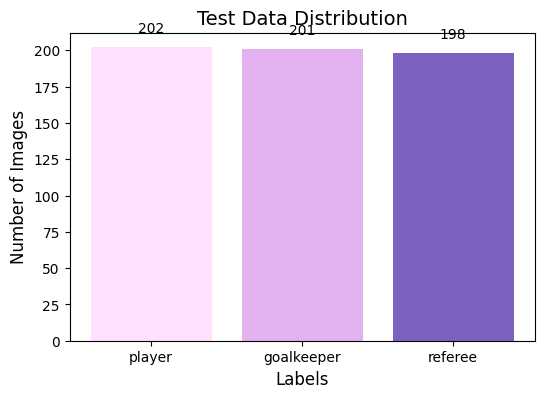

In [19]:
# Tạo biểu đồ cột (bar chart) để hiển thị phân phối số lượng mẫu theo từng nhãn (label_test) trong tập dữ liệu df_test
# Màu sắc tùy chỉnh
color = ['#FFE1FF', '#E4B1F0', '#7E60BF', '#433878']
# Đếm số lượng mẫu của mỗi nhãn
label_counts = df_test['label_test'].value_counts()
# Vẽ biểu đồ
plt.figure(figsize=(6,4))
plt.bar(label_counts.index, label_counts.values, color = color)
# Thêm tiêu đề và nhãn của các trục
plt.title('Test Data Distribution', fontsize=14)
plt.xlabel('Labels', fontsize=12)
plt.ylabel('Number of Images', fontsize=12)
# Hiển thị giá trị trên từng cột
for i, v in enumerate(label_counts.values):
    plt.text(i, v + 10, f"{v:,}", ha='center', fontsize=10)
# Hiển thị biểu đồ
plt.show()

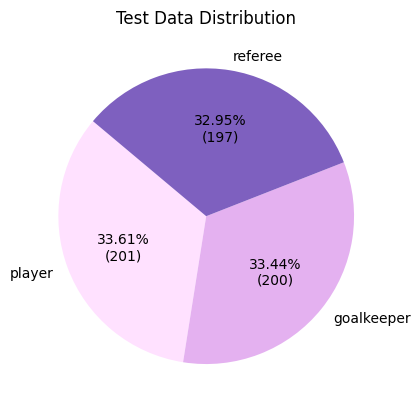

In [20]:
# Tạo biểu đồ tròn (pie chart) để hiển thị phân phối số lượng mẫu theo từng nhãn (label_trest) trong tập dữ liệu df_test
# Đếm số lượng mẫu của mỗi nhãn
label_counts = df_test['label_test'].value_counts()
# Vẽ biểu đồ tròn
plt.pie(label_counts, 
        labels=label_counts.index, 
        colors = color, 
        autopct=lambda p: f'{p:.2f}%\n({int(p * label_counts.sum() / 100):,})', # Hiển thị cả số lượng mẫu
        startangle=140 # Xoay biểu đồ để có góc nhìn đẹp hơn
       )
# Thêm tiêu đề
plt.title('Test Data Distribution')
# Hiển thị biểu đồ
plt.show()

In [21]:
# Hiển thị số lượng mẫu của từng nhãn trong cột label_test (theo thứ tự giảm dần)
print(df_test['label_test'].value_counts().apply(lambda x: f"{x:,}"))

label_test
player        202
goalkeeper    201
referee       198
Name: count, dtype: object


In [22]:
# Hiển thị số lượng dòng (rows) và cột (columns) của DataFrame df_test
print(f'This test data has {df_test.shape[0]:,} rows and {df_test.shape[1]:,} columns')

This test data has 601 rows and 2 columns


<h2 style="background-color: #367E7F; color: white; padding: 15px; text-align: center; font-size: 20px; border-radius: 6px; font-weight: bold;">
    4. Data Preprocessing
</h2>

<h2 style="background-color: #367E7F; color: white; padding: 15px; text-align: center; font-size: 20px; border-radius: 6px; font-weight: bold;">
    4.1 Creating an image data generator for training and testing data
</h2>

In [23]:
# Tạo các bộ tạo dữ liệu hình ảnh
# Bổ sung thêm các phép biến đổi giúp mô hình học tốt hơn
data_train_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,     # Xoay ảnh trong khoảng ±20 độ
    width_shift_range=0.15, # Dịch ảnh theo chiều ngang
    height_shift_range=0.15,# Dịch ảnh theo chiều dọc
    shear_range=0.15,       # Biến dạng affine
    zoom_range=0.15,        # Phóng to hoặc thu nhỏ ảnh
    horizontal_flip=True,  # Lật ảnh ngẫu nhiên theo chiều ngang
    brightness_range=(0.8, 1.2),  # Thêm tăng giảm độ sáng    
    fill_mode='nearest'    # Điền giá trị khi thực hiện các phép biến đổi
    #fill_mode='reflect'     # Tránh viền giả tạo
)
#data_train_gen = ImageDataGenerator(rescale = 1./255)
data_valid_gen = ImageDataGenerator(rescale = 1./255)
data_test_gen = ImageDataGenerator(rescale = 1./255)

# rescale=1./255: Chia mỗi giá trị pixel của ảnh cho 255 để chuẩn hóa về khoảng [0,1] (thay vì [0,255]).
# Điều này giúp mô hình học nhanh hơn và tránh các vấn đề về giá trị lớn khi huấn luyện.

<h2 style="background-color: #367E7F; color: white; padding: 15px; text-align: center; font-size: 20px; border-radius: 8px; font-weight: bold;">
    4.2 Generating batches of image data for training, validation, and testing
</h2>

In [24]:
# Tạo các bộ dữ liệu huấn luyện (train), kiểm tra (test), và đánh giá (pred) từ các DataFrame chứa đường dẫn ảnh (filepath_*) và nhãn (label_*)

# Tạo dữ liệu huấn luyện (train_gen) - (có augmentation)
train_gen = data_train_gen.flow_from_dataframe(
    df_train,
    x_col = 'filepath_train',
    y_col = 'label_train',
    target_size = (IMAGE_SIZE[0], IMAGE_SIZE[1]), # Resize ảnh về kích thước (IMAGE_SIZE[0], IMAGE_SIZE[1]) trước khi đưa vào mô hình
    class_mode = 'categorical', # Đây là bài toán phân loại nhiều lớp, nhãn được mã hóa theo one-hot encoding
    shuffle = True, # Trộn dữ liệu trước khi đưa vào mô hình để tránh hiện tượng learning bias
    batch_size = BATCH_SIZE, # Số lượng ảnh trong mỗi batch khi huấn luyện
    seed=42  # Đảm bảo kết quả nhất quán giữa các lần chạy
)

# Tạo dữ liệu kiểm tra (valid_gen) - (không augmentation)
# Không trộn dữ liệu, giữ nguyên thứ tự mẫu để đảm bảo kết quả kiểm tra ổn định
valid_gen = data_valid_gen.flow_from_dataframe(
    df_test,
    x_col='filepath_test',
    y_col='label_test',
    target_size=(IMAGE_SIZE[0], IMAGE_SIZE[1]),
    class_mode='categorical',
    shuffle=False,
    batch_size=BATCH_SIZE,
)

# Tạo dữ liệu kiểm tra cuối cùng (test_gen) - (không augmentation)
# Không trộn dữ liệu, giữ nguyên thứ tự mẫu để đảm bảo kết quả kiểm tra ổn định
test_gen = data_valid_gen.flow_from_dataframe(
    df_test,
    x_col='filepath_test',
    y_col='label_test',
    target_size=(IMAGE_SIZE[0], IMAGE_SIZE[1]),
    class_mode='categorical',
    shuffle=False,
    batch_size=BATCH_SIZE
)

Found 2385 validated image filenames belonging to 3 classes.
Found 601 validated image filenames belonging to 3 classes.
Found 601 validated image filenames belonging to 3 classes.


<h2 style="background-color: #367E7F; color: white; padding: 15px; text-align: center; font-size: 20px; border-radius: 6px; font-weight: bold;">
    4.3 Retrieving the class-to-index mapping from the training data generator
</h2>

In [25]:
# Trả về một dictionary ánh xạ từng nhãn (class label) với chỉ số tương ứng (index)
# Dùng để chuyển từ số về nhãn khi dự đoán (predictions → labels)
class_dict = train_gen.class_indices
print("Mapping between class names and numerical labels:")
class_dict

Mapping between class names and numerical labels:


{'goalkeeper': 0, 'player': 1, 'referee': 2}

<div style="background-color: #367E7F; color: white; padding: 15px; text-align: center; font-size: 20px; border-radius: 6px; font-weight: bold;">
    Inspecting the shape of image and label batches from the training generator
</div>

In [26]:
# Kiểm tra kích thước của 1 batch dữ liệu trong tập huấn luyện
for batch_image, batch_label in train_gen:
    print(f"Batch image shape (batch_size, height, width, channels): {batch_image.shape}")
    print(f"Batch label shape (batch_size, num_classes or 1): {batch_label.shape}")
    break

Batch image shape (batch_size, height, width, channels): (32, 224, 224, 3)
Batch label shape (batch_size, num_classes or 1): (32, 3)


In [27]:
# Số lượng batch trong tập huấn luyện
print(f"Number of training batches: {len(train_gen)}")

Number of training batches: 75


<h2 style="background-color: #367E7F; color: white; padding: 15px; text-align: center; font-size: 20px; border-radius: 6px; font-weight: bold;">
    4.4 Visualizing a batch of training images
</h2>

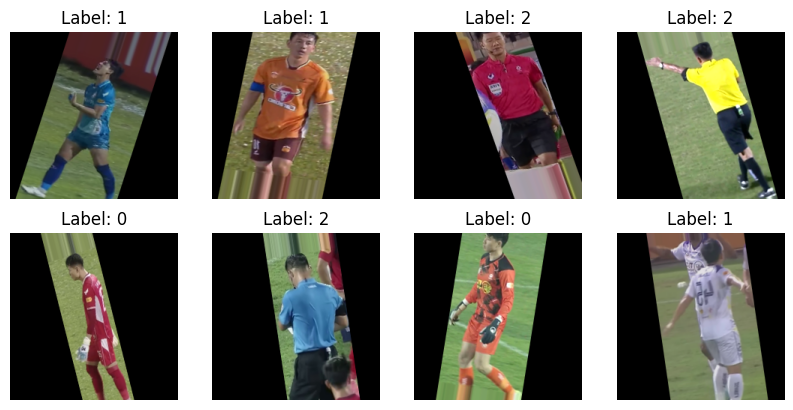

In [28]:
# Vẽ ảnh từ batch để kiểm tra xem dữ liệu đã load đúng chưa
for batch_imge, batch_label in train_gen:
    # Hiển thị 5 ảnh đầu tiên
    plt.figure(figsize = (10, 10))
    for i in range(8):
        plt.subplot(4, 4, i+1)
        plt.imshow(batch_imge[i])
        plt.title(f"Label: {np.argmax(batch_label[i])}")  # Hiển thị label (chuyển one-hot về số)
        plt.axis('off')
    break

<h2 style="background-color: #367E7F; color: white; padding: 15px; text-align: center; font-size: 20px; border-radius: 6px; font-weight: bold;">
    5. Build the Deep Learning Model
</h2>

<h2 style="background-color: #367E7F; color: white; padding: 15px; text-align: center; font-size: 20px; border-radius: 6px; font-weight: bold;">
    5.1 Defining a Convolutional Neural Network (CNN) for Image Classification
</h2>

In [29]:
# Xây dựng một mô hình Convolutional Neural Network (CNN) bằng Sequential() trong TensorFlow/Keras
# Mô hình này thực hiện trích xuất đặc trưng từ ảnh và phân loại thành 3 lớp (Dense(3, activation='softmax'))
model2 = Sequential([
    #lớp tích chập với 64 filter kích thước 3x3 => Trích xuất đặc trưng ảnh
    #padding=same: giữ lại kích thước ảnh sau khi tích chập
    #activation='relu': dùng ReLu để loại bỏ giá trị âm (tăng tốc huấn luyện)

    # 🧩 Lớp tích chập đầu tiên
    # ✅ Hai lớp tích chập (Conv2D):
    #   64 bộ lọc (filter) kích thước 3×3
    #   padding='same': Kích thước ảnh đầu vào và đầu ra không đổi
    #   activation='relu': Giữ lại giá trị dương, giúp mô hình hội tụ nhanh hơn
    # ✅ Lớp pooling (MaxPooling2D):
    #   Giảm kích thước ảnh còn 1/2 bằng cách lấy giá trị lớn nhất trong ô 2×2
    #   Giúp giảm số lượng tham số, tránh overfitting
    Conv2D(64, kernel_size= (3,3), padding='same', activation='relu', input_shape=(IMAGE_SIZE[0],IMAGE_SIZE[1],3)),
    #BatchNormalization(), # Giúp mô hình hội tụ nhanh hơn và ổn định hơn
    Conv2D(64, kernel_size= (3,3), padding='same', activation='relu'),
    #BatchNormalization(),
    MaxPooling2D((2,2)), # giảm kích thước ảnh bằng cách lấy max trong ô 2x2
    Dropout(0.2),

    # 🧩 Lớp tích chập thứ hai
    # ✅ Bộ lọc tăng lên 128:
    #   Học được các đặc trưng phức tạp hơn, như góc cạnh hoặc texture
    #   Giúp mô hình nhận diện đối tượng tốt hơn
    # ✅ Giảm kích thước ảnh lần nữa (MaxPooling2D)
    Conv2D(128, kernel_size= (3,3), padding='same', activation='relu'),   
    #BatchNormalization(),
    Conv2D(128, kernel_size= (3,3), padding='same', activation='relu'),    
    #BatchNormalization(),
    MaxPooling2D((2,2)),
    Dropout(0.3),
    
    # Lớp tích chập thứ ba
    #   Giữ nguyên số lượng bộ lọc (128 filter) nhưng trích xuất thêm đặc trưng
    #   Tiếp tục giảm kích thước ảnh để tập trung vào các đặc trưng quan trọng
    Conv2D(128, kernel_size= (3,3),padding='same', activation='relu'),    
    BatchNormalization(),
    Conv2D(128, kernel_size= (3,3),padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2,2)),
    Dropout(0.3),
    
    # Lớp tích chập thứ tư
    #   Tăng số lượng filter lên 256
    #   Giúp mô hình phát hiện hình dạng phức tạp (mắt, mũi, tai nếu là nhận diện khuôn mặt)
    #   Tiếp tục giảm kích thước ảnh
    Conv2D(256, kernel_size= (3,3),padding='same', activation='relu'),   
    BatchNormalization(),
    Conv2D(256, kernel_size= (3,3),padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2,2)),
    Dropout(0.4),
    
    # Hai lớp tích chập cuối cùng
    #   Số lượng bộ lọc tăng lên 256 rồi 512 → nhận diện đặc trưng cấp cao nhất
    #   Đây là các lớp deepest, giúp mô hình hiểu toàn bộ cấu trúc ảnh
    #   Ảnh lúc này rất nhỏ, nhưng chứa thông tin quan trọng
    Conv2D(512, kernel_size= (3,3),padding='same', activation='relu'),
    BatchNormalization(),
    Conv2D(512, kernel_size= (3,3),padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2,2)),
    Dropout(0.4),

    #Conv2D(512, kernel_size= (3,3),padding='same', activation='relu'),
    #BatchNormalization(),
    #Conv2D(512, kernel_size= (3,3),padding='same', activation='relu'),
    #BatchNormalization(),
    #MaxPooling2D((2,2)),
    #Dropout(0.4),
    
    # Fully Connected Layers (MLP - Mạng nơ-ron truyền thống)
    #Flatten(), # Chuyển đổi tensor 3D thành vector 1D để đưa vào fully connected    
    GlobalAveragePooling2D(), # Thay Flatten() bằng GlobalAveragePooling2D() để giảm số tham số và giúp mô hình tổng quát hóa tốt hơn
    Dense(256, activation='relu'), # Fully connected layer với 256 neuron học các đặc trưng trừu tượng hơn
    #Dropout(0.3),
    Dense(64, activation='relu'), # 64 neuron để giảm kích thước tránh overfitting
    Dropout(0.4), # Loại bỏ ngẫu nhiên 30% số neuron để tránh overfitting, tăng tính tổng quát hóa
    # Dropout(0.3): 0.3 có thể chưa đủ để tránh overfitting, thử tăng lên 0.4 - 0.5 để tránh mô hình học quá kỹ trên tập huấn luyện
    
    Dense(3, activation='softmax') ]) # Lớp output: có 3 lớp phân loại nên số neuron là 3
    # softmax giúp mô hình trả về xác suất cho từng lớp

I0000 00:00:1745676762.442927      31 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


### Kiến trúc AlexNet (2012)

In [30]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dropout, Flatten, Dense, BatchNormalization
from tensorflow.keras.optimizers import Adam

model = Sequential([
    Conv2D(96, (11, 11), strides=4, activation='relu', input_shape=(IMAGE_SIZE[0],IMAGE_SIZE[1], 3)),
    BatchNormalization(),
    MaxPooling2D(pool_size=(3, 3), strides=2),

    Conv2D(256, (5, 5), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(3, 3), strides=2),

    Conv2D(384, (3, 3), padding='same', activation='relu'),
    Conv2D(384, (3, 3), padding='same', activation='relu'),
    Conv2D(256, (3, 3), padding='same', activation='relu'),
    MaxPooling2D(pool_size=(3, 3), strides=2),

    Flatten(),
    Dense(4096, activation='relu'),
    Dropout(0.5),
    Dense(4096, activation='relu'),
    Dropout(0.5),
    Dense(3, activation='softmax')  # 3 lớp: player, goalkeeper, referee
])

In [31]:
# Hiển thị sơ đồ kiến trúc mô hình dạng hình ảnh
#from tensorflow.keras.utils import plot_model
#plot_model(model, show_shapes=True, show_layer_names=True)

In [32]:
# Xem kiến trúc mô hình 
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_10 (Conv2D)                   │ (None, 54, 54, 96)          │          34,944 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_6                │ (None, 54, 54, 96)          │             384 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (None, 26, 26, 96)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_11 (Conv2D)                   │ (None, 26, 26, 256)         │         614,656 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_7                │ (None, 26, 26, 256)         │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_6 (MaxPooling2D)       │ (None, 12, 12, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_12 (Conv2D)                   │ (None, 12, 12, 384)         │         885,120 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_13 (Conv2D)                   │ (None, 12, 12, 384)         │       1,327,488 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_14 (Conv2D)                   │ (None, 12, 12, 256)         │         884,992 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_7 (MaxPooling2D)       │ (None, 5, 5, 256)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 6400)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 4096)                │      26,218,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_6 (Dropout)                  │ (None, 4096)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 4096)                │      16,781,312 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_7 (Dropout)                  │ (None, 4096)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 3)                   │          12,291 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 46,760,707 (178.38 MB)

 Trainable params: 46,760,003 (178.38 MB)

 Non-trainable params: 704 (2.75 KB)

In [33]:
# Biên dịch (compile) mô hình CNN trước khi huấn luyện
# Hàm mất mát (loss function) đo lường sự khác biệt giữa dự đoán và nhãn thực tế
# Theo dõi độ chính xác (accuracy) trong quá trình huấn luyện
model.compile(
    optimizer=Adamax(learning_rate=0.0005),
    loss='categorical_crossentropy', 
    metrics=['accuracy']
)

<h2 style="background-color: #367E7F; color: white; padding: 15px; text-align: center; font-size: 20px; border-radius: 6px; font-weight: bold;">
    5.2 Training the CNN model with early stopping
</h2>

In [34]:
# Huấn luyện mô hình CNN bằng cách sử dụng dữ liệu huấn luyện (train_gen) và kiểm tra với dữ liệu validation (valid_gen)
# train_gen: tập dữ liệu huấn luyện (ảnh đã được tăng cường dữ liệu và chuẩn hóa)
# valid_gen: tập dữ liệu kiểm tra, dùng để đánh giá mô hình sau mỗi epoch (không áp dụng tăng cường dữ liệu, chỉ chuẩn hóa ảnh)
# epochs: số vòng lặp huấn luyện (epoch là 1 lần duyệt qua toàn bộ dữ liệu huấn luyện)
# EarlyStopping giúp dừng huấn luyện sớm nếu mô hình không cải thiện
#   monitor='val_accuracy' và mode='max'giúp mô hình dừng sớm theo val_accuracy thay vì val_loss
#   patience=5: Nếu val_loss không giảm sau 5 epochs, mô hình sẽ tự động dừng để tránh overfitting.
#   restore_best_weights=True: Khôi phục trọng số tốt nhất thay vì lấy trọng số ở epoch cuối.
# Lưu mô hình tốt nhất toàn bộ
best_train_acc = 0.0
best_val_acc = 0.0
best_model_path = ""
best_history = None
for run in range(1, 3):
    print(f"\n🔁 Training round {run}")
    model_path = f"model_run{run}.keras"

    # Reset optimizer mỗi lần huấn luyện
    model.compile(
        optimizer=Adamax(learning_rate=0.0005),
        loss='categorical_crossentropy', 
        metrics=['accuracy']
    )
    
    history = model.fit(
        train_gen,
        validation_data = valid_gen,
        epochs = 50,
        callbacks = [
            EarlyStopping(monitor='val_accuracy', mode='max', patience = 5, restore_best_weights = True),
            # Giảm learning rate khi val_loss không giảm        
            ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1, min_lr=1e-6),
            ModelCheckpoint(model_path, monitor='val_accuracy', save_best_only=True, mode='max', verbose=1)
        ]
    )

    # Lấy val_acc tốt nhất trong lịch sử huấn luyện    
    history_data = history.history    
    # Tìm chỉ số epoch có val_accuracy cao nhất
    val_index = history_data['val_accuracy'].index(max(history_data['val_accuracy']))    
    # Lấy các giá trị tương ứng tại epoch đó
    val_acc = history_data['val_accuracy'][val_index]
    corresponding_train_acc = history_data['accuracy'][val_index]
    epoch = val_index + 1  # Epoch bắt đầu từ 1    
    print(f"✅ Run {run} best val_accuracy: {val_acc:.4f}, train accuracy: {corresponding_train_acc:.4f}, epoch: {epoch}")
    
    if val_acc > best_val_acc:
        best_train_acc = corresponding_train_acc
        best_val_acc = val_acc
        best_model_path = model_path
        best_history = history_data.copy()

history = best_history

print(f"\n🏆 Best model: {best_model_path} with val_accuracy = {best_val_acc:.4f}, train accuracy = {best_train_acc:.4f}")


🔁 Training round 1
Epoch 1/50


I0000 00:00:1745676774.256528      94 service.cc:148] XLA service 0x7f4ed8006c50 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1745676774.257277      94 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1745676774.674731      94 cuda_dnn.cc:529] Loaded cuDNN version 90300


 1/75 ━━━━━━━━━━━━━━━━━━━━ 19:13 16s/step - accuracy: 0.4062 - loss: 1.5069

I0000 00:00:1745676780.610012      94 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


74/75 ━━━━━━━━━━━━━━━━━━━━ 0s 619ms/step - accuracy: 0.3868 - loss: 2.8725
Epoch 1: val_accuracy improved from -inf to 0.42263, saving model to model_run1.keras
75/75 ━━━━━━━━━━━━━━━━━━━━ 72s 763ms/step - accuracy: 0.3887 - loss: 2.8361 - val_accuracy: 0.4226 - val_loss: 1.0605 - learning_rate: 5.0000e-04
Epoch 2/50
74/75 ━━━━━━━━━━━━━━━━━━━━ 0s 394ms/step - accuracy: 0.6035 - loss: 0.8401
Epoch 2: val_accuracy improved from 0.42263 to 0.61398, saving model to model_run1.keras
75/75 ━━━━━━━━━━━━━━━━━━━━ 38s 460ms/step - accuracy: 0.6041 - loss: 0.8394 - val_accuracy: 0.6140 - val_loss: 0.9341 - learning_rate: 5.0000e-04
Epoch 3/50
74/75 ━━━━━━━━━━━━━━━━━━━━ 0s 392ms/step - accuracy: 0.7119 - loss: 0.6740
Epoch 3: val_accuracy did not improve from 0.61398
75/75 ━━━━━━━━━━━━━━━━━━━━ 34s 414ms/step - accuracy: 0.7119 - loss: 0.6737 - val_accuracy: 0.5840 - val_loss: 0.9407 - learning_rate: 5.0000e-04
Epoch 4/50
74/75 ━━━━━━━━━━━━━━━━━━━━ 0s 400ms/step - accuracy: 0.7362 - loss: 0.6027
Epo

<h2 style="background-color: #367E7F; color: white; padding: 15px; text-align: center; font-size: 20px; border-radius: 6px; font-weight: bold;">
    5.3 Evaluating the model on training, validation, and test datasets
</h2>

In [35]:
# Đánh giá mô hình trên từng tập dữ liệu (train, valid, test) bằng cách tính loss và accuracy.
print(model.evaluate(train_gen))
print(model.evaluate(valid_gen))
print(model.evaluate(test_gen))

75/75 ━━━━━━━━━━━━━━━━━━━━ 32s 431ms/step - accuracy: 0.9768 - loss: 0.0773
[0.07248067110776901, 0.9752620458602905]
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 103ms/step - accuracy: 0.9329 - loss: 0.2596
[0.22458764910697937, 0.9450914859771729]
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 99ms/step - accuracy: 0.9329 - loss: 0.2596
[0.22458764910697937, 0.9450914859771729]


<h2 style="background-color: #367E7F; color: white; padding: 15px; text-align: center; font-size: 20px; border-radius: 6px; font-weight: bold;">
    5.4 Saving the trained model to a file
</h2>

In [36]:
# Lưu toàn bộ mô hình (bao gồm kiến trúc, trọng số và optimizer) vào một file có tên Model_intel_ACC87.h5
#model.save('Model_vleague_2425.keras')

In [37]:
import glob

# Tìm tất cả các file .h5 trong thư mục hiện tại
model_files = glob.glob("*.h5")

if model_files:
    print("Danh sách mô hình đã lưu:")
    for model in model_files:
        print("-", model)
else:
    print("Không có mô hình nào được lưu.")

Không có mô hình nào được lưu.


<h2 style="background-color: #367E7F; color: white; padding: 15px; text-align: center; font-size: 20px; border-radius: 6px; font-weight: bold;">
    6. Predictions & Model Analysis
</h2>

<h2 style="background-color: #367E7F; color: white; padding: 15px; text-align: center; font-size: 20px; border-radius: 6px; font-weight: bold;">
    6.1 Making predictions on the test dataset
</h2>

<div style="background-color: #595959; color: white"><b><span style="color: orange">[Run on Demand]</span></b> Để tối ưu thời gian huấn luyện mô hình, có thể cần load mô hình đã được huấn luyện</div>

In [38]:
#from tensorflow.keras.models import load_model

# Tải và sử dụng mô hình có sẵn
#model_path = '/kaggle/working/Model_vleague_2425.keras'  # Đường dẫn file mô hình

# Kiểm tra nếu mô hình tồn tại
#if os.path.exists(model_path):
#    print("✅ Mô hình tồn tại, đang tải...")
#    model = load_model(model_path)
#    print("✅ Tải mô hình thành công!")
#else:
#    print("❌ Không tìm thấy mô hình! Hãy kiểm tra lại đường dẫn hoặc huấn luyện lại mô hình.")

In [39]:
# dự đoán nhãn trên tập kiểm tra (test_gen)
preds = model.predict(test_gen) # Dự đoán trên tập test, trả về ma trận xác suất 
y_pred = np.argmax(preds, axis=1) # Chuyển xác suất thành nhãn dự đoán

19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 125ms/step


<h2 style="background-color: #367E7F; color: white; padding: 15px; text-align: center; font-size: 20px; border-radius: 6px; font-weight: bold;">
    6.2 Generating and visualizing the confusion matrix
</h2>

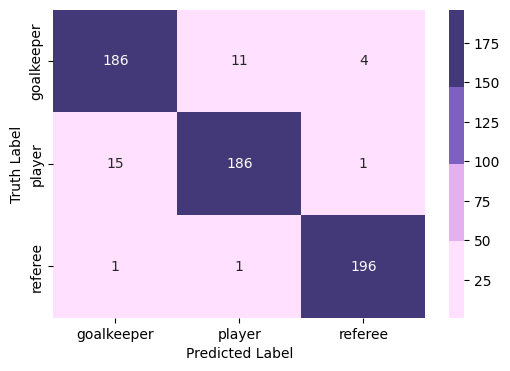

In [40]:
# vẽ ma trận nhầm lẫn (confusion matrix) để phân tích lỗi của mô hình trên tập validation
# valid_gen.classes: lấy nhãn thực tế (ground truth) từ tập validation
# y_pred: nhãn dự đoán từ mô hình
# Tạo ma trận nhầm lẫn, cho biết mô hình nhầm lẫn giữa các lớp nào
cm = confusion_matrix(valid_gen.classes, y_pred)
labels = list(class_dict.keys())
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap=color, xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted Label')
plt.ylabel('Truth Label')
plt.show()

<h2 style="background-color: #367E7F; color: white; padding: 15px; text-align: center; font-size: 20px; border-radius: 6px; font-weight: bold;">
    6.3 Plotting the training and validation accuracy over epochs
</h2>

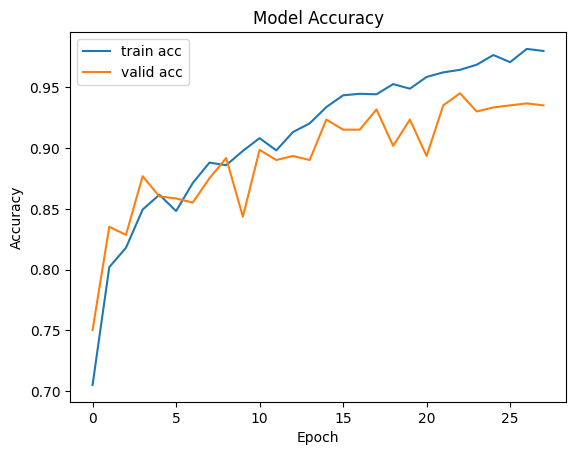

In [41]:
# Vẽ biểu đồ Accuracy (độ chính xác) của mô hình trong quá trình huấn luyện (theo epoch)
plt.plot(history.history['accuracy']) # Vẽ độ chính xác trên tập huấn luyện (train accuracy)
plt.plot(history.history['val_accuracy']) # Vẽ độ chính xác trên tập validation (validation accuracy)

plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['train acc', 'valid acc'], loc='upper left')

<h2 style="background-color: #367E7F; color: white; padding: 15px; text-align: center; font-size: 20px; border-radius: 6px; font-weight: bold;">
    6.4 Plotting the training and validation loss over epochs
</h2>

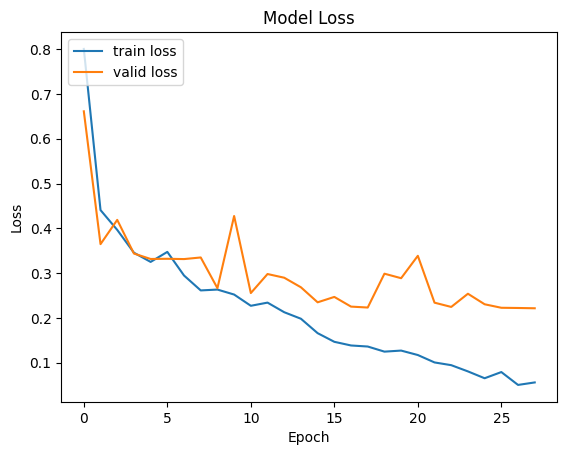

In [42]:
# Vẽ biểu đồ Loss (hàm mất mát) của mô hình trong quá trình huấn luyện (theo epoch)
plt.plot(history.history['loss']) # Vẽ loss trên tập huấn luyện (train loss)
plt.plot(history.history['val_loss']) # Vẽ loss trên tập validation (validation loss)

plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['train loss', 'valid loss'], loc='upper left')

<h2 style="background-color: #367E7F; color: white; padding: 15px; text-align: center; font-size: 20px; border-radius: 6px; font-weight: bold;">
    6.5 Function to predict the class of an input image and visualize the results
</h2>

In [43]:
# Hàm dự đoán nhãn cho một ảnh đầu vào bằng mô hình Model, đồng thời hiển thị ảnh và biểu đồ xác suất của từng lớp
def predict(img_path):    
    label = list(class_dict.keys())
    plt.figure(figsize=(8, 6))
    
    #img = Image.open(img_path)
    # Mở ảnh và chuyển sang RGB (loại bỏ kênh Alpha nếu có)
    img = Image.open(img_path).convert('RGB')
    
    resized_img = img.resize((IMAGE_SIZE[0], IMAGE_SIZE[1]))
    img = np.asarray(resized_img)
    img = np.expand_dims(img, axis=0)
    img = img / 255
    predictions = model.predict(img)
    probs = list(predictions[0])
    labels = label
    plt.subplot(2, 1, 1)
    plt.imshow(resized_img)
    plt.subplot(2, 1, 2)
    bars = plt.barh(labels, probs)
    plt.xlabel('Probability', fontsize=15)
    ax = plt.gca()
    ax.bar_label(bars, fmt = '%.2f')
    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 887ms/step


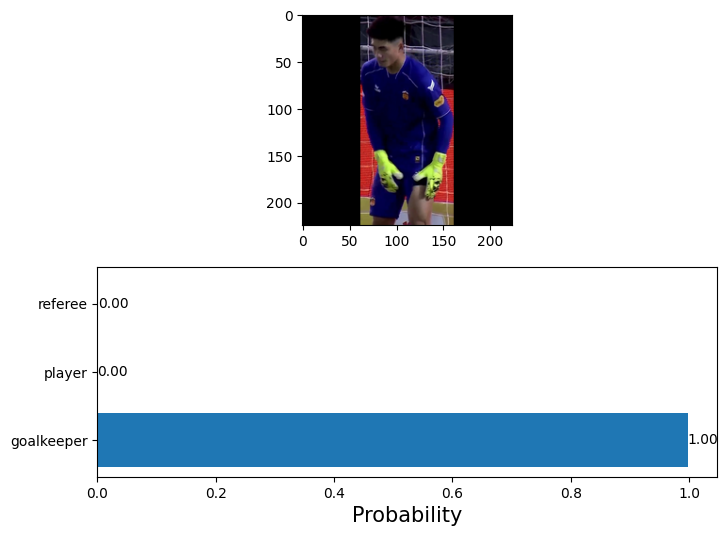

In [44]:
predict(pred_dir + '/goalkeeper/21.HAGLVHN7_f0819_p00.jpg')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step


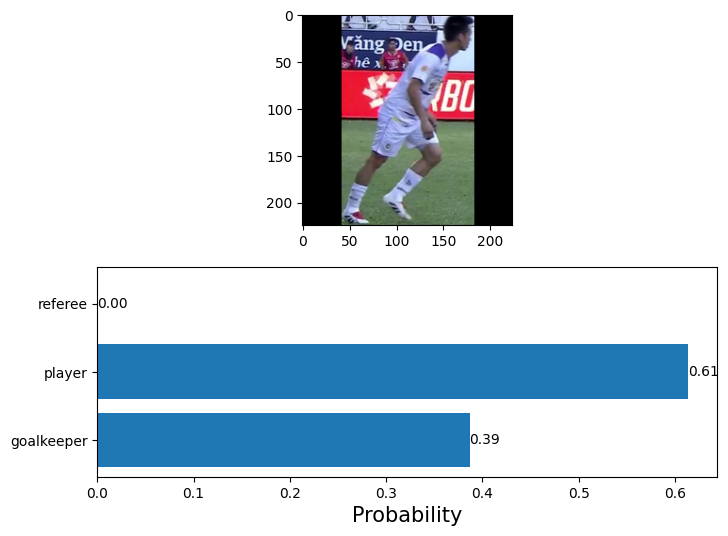

In [45]:
predict(pred_dir + '/player/21.HAGLVHN7_f0194_p00.jpg')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step


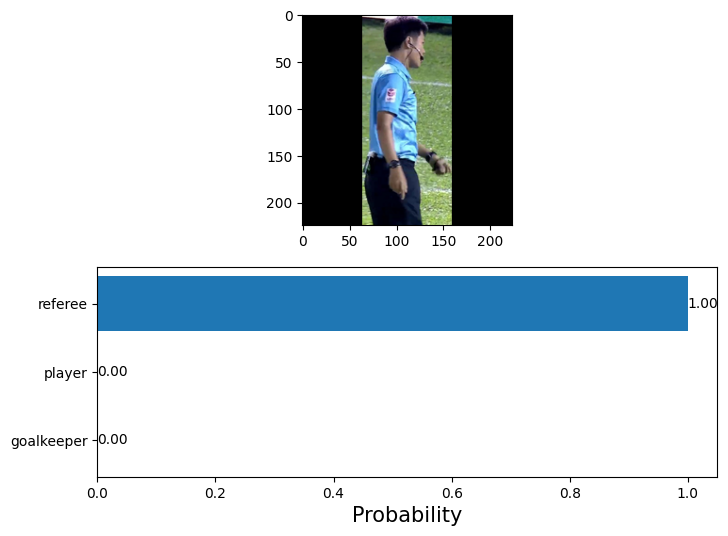

In [46]:
predict(pred_dir + '/referee/21.HAGLVHN7_f0570_p00.jpg')

<h2 style="background-color: #367E7F; color: white; padding: 15px; text-align: center; font-size: 20px; border-radius: 6px; font-weight: bold;">
    6.6 Analyze the model's prediction results on the test set
</h2>

### Dùng mô hình để dự đoán ảnh một số ảnh

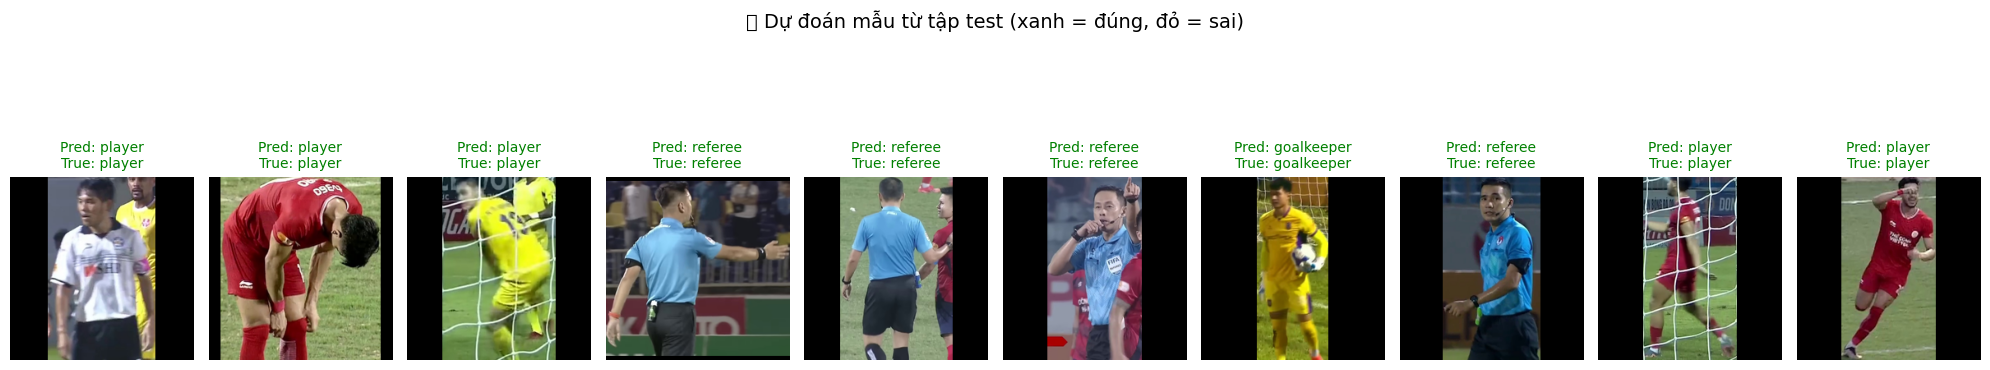

In [47]:
import numpy as np
import matplotlib.pyplot as plt

# Lấy dữ liệu và nhãn thật từ test_gen
X_test, y_true = [], []
for i in range(len(test_gen)):
    x_batch, y_batch = test_gen[i]
    X_test.extend(x_batch)
    y_true.extend(np.argmax(y_batch, axis=1))
X_test = np.array(X_test)
y_true = np.array(y_true)

# Dự đoán
#preds = model.predict(X_test)
#y_pred = np.argmax(preds, axis=1)

# Hiển thị 10 ảnh test bất kỳ kèm nhãn dự đoán và nhãn thật
num_images = 10
plt.figure(figsize=(20, 5))
labels = list(class_dict.keys())

for i in range(num_images):
    index = np.random.randint(0, len(X_test))
    img = X_test[index]
    
    plt.subplot(1, num_images, i + 1)
    plt.imshow(img)
    plt.axis('off')
    
    true_label = labels[y_true[index]]
    pred_label = labels[y_pred[index]]
    color_title = 'green' if y_true[index] == y_pred[index] else 'red'
    plt.title(f"Pred: {pred_label}\nTrue: {true_label}", color=color_title, fontsize=10)

plt.suptitle("📷 Dự đoán mẫu từ tập test (xanh = đúng, đỏ = sai)", fontsize=14)
plt.tight_layout()
plt.show()

### Hiển thị các ảnh sai dự đoán để phân tích kỹ hơn

🔍 Tổng số ảnh dự đoán sai: 33


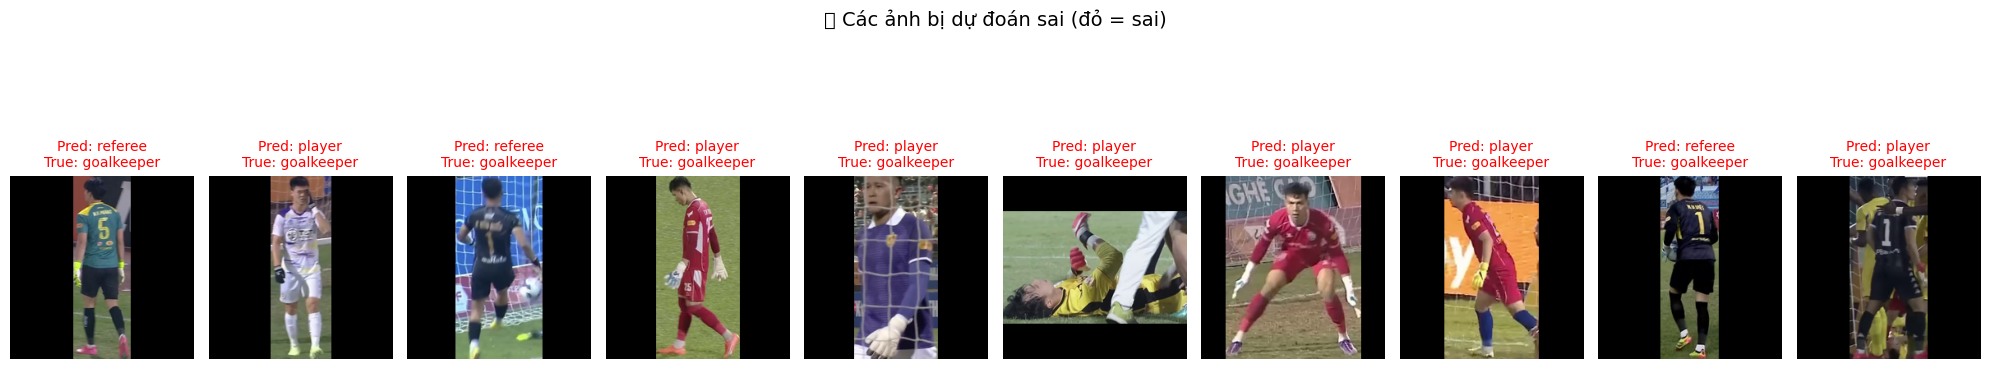

In [48]:
import numpy as np
import matplotlib.pyplot as plt

# Tìm chỉ số các ảnh bị dự đoán sai
wrong_indices = np.where(y_pred != y_true)[0]
print(f"🔍 Tổng số ảnh dự đoán sai: {len(wrong_indices)}")

# Hiển thị 10 ảnh bị dự đoán sai
num_images = min(10, len(wrong_indices))  # đảm bảo không vượt quá số lượng sai
plt.figure(figsize=(20, 5))
labels = list(class_dict.keys())

for i in range(num_images):
    idx = wrong_indices[i]
    img = X_test[idx]

    plt.subplot(1, num_images, i + 1)
    plt.imshow(img)
    plt.axis('off')

    true_label = labels[y_true[idx]]
    pred_label = labels[y_pred[idx]]
    plt.title(f"Pred: {pred_label}\nTrue: {true_label}", color='red', fontsize=10)

plt.suptitle("📛 Các ảnh bị dự đoán sai (đỏ = sai)", fontsize=14)
plt.tight_layout()
plt.show()

### Tìm xem mô hình thường hay nhầm lớp nào thành lớp nào nhất

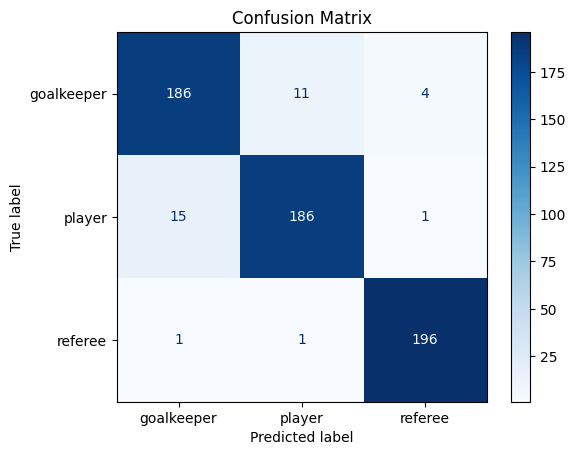


🔍 Top 5 lỗi dự đoán phổ biến nhất:
- Dự đoán nhầm 'player' thành 'goalkeeper': 15 lần
- Dự đoán nhầm 'goalkeeper' thành 'player': 11 lần
- Dự đoán nhầm 'goalkeeper' thành 'referee': 4 lần
- Dự đoán nhầm 'player' thành 'referee': 1 lần
- Dự đoán nhầm 'referee' thành 'goalkeeper': 1 lần


In [49]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Tạo confusion matrix
cm = confusion_matrix(y_true, y_pred)
labels = list(class_dict.keys())
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap='Blues', values_format='d')
plt.title("Confusion Matrix")
plt.show()

# Tìm các lỗi phổ biến nhất (trừ đường chéo chính)
errors = []
for true_label in range(len(labels)):
    for pred_label in range(len(labels)):
        if true_label != pred_label:
            errors.append(((labels[true_label], labels[pred_label]), cm[true_label][pred_label]))

# Sắp xếp lỗi theo tần suất giảm dần
errors_sorted = sorted(errors, key=lambda x: x[1], reverse=True)

# In ra top 5 lỗi phổ biến
print("\n🔍 Top 5 lỗi dự đoán phổ biến nhất:")
for (true_class, pred_class), count in errors_sorted[:5]:
    if count > 0:
        print(f"- Dự đoán nhầm '{true_class}' thành '{pred_class}': {count} lần")

### Hiển thị ảnh bị nhầm từ "player" thành "goalkeeper"

🔎 Số lượng ảnh bị nhầm 'player' → 'goalkeeper': 15


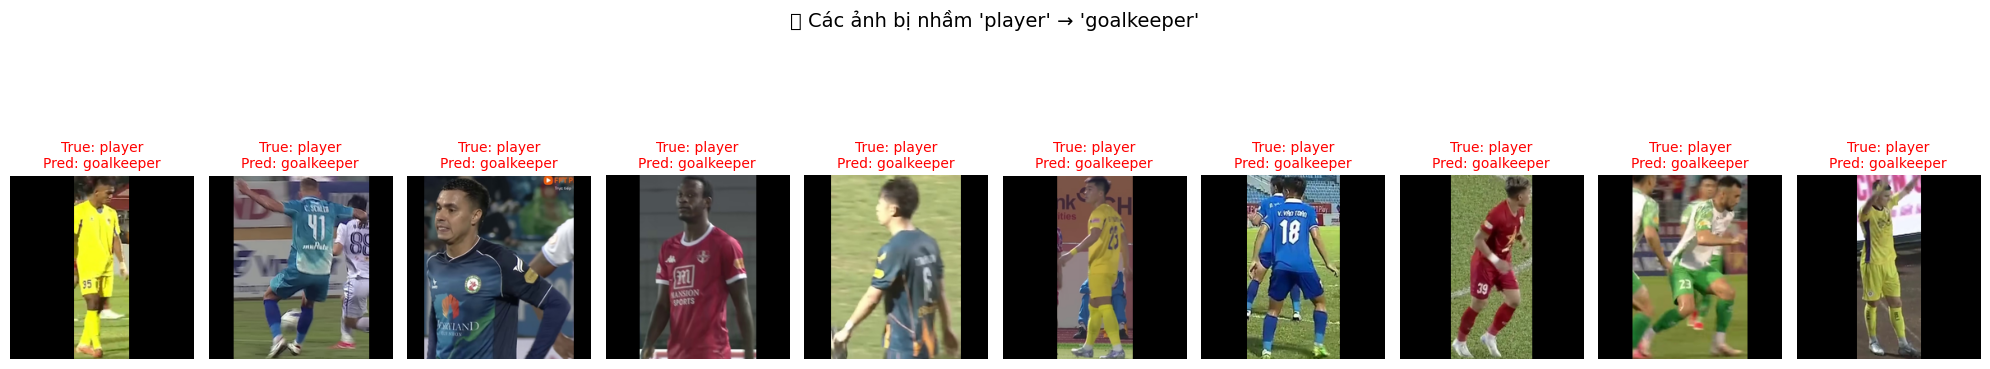

In [50]:
import matplotlib.pyplot as plt
import numpy as np

# Chọn lớp thật và lớp bị nhầm
true_class = 'player'
pred_class = 'goalkeeper'

true_label = class_dict[true_class]
pred_label = class_dict[pred_class]

# Lấy chỉ số các ảnh bị nhầm đúng kiểu này
wrong_indices = np.where((y_true == true_label) & (y_pred == pred_label))[0]

print(f"🔎 Số lượng ảnh bị nhầm '{true_class}' → '{pred_class}': {len(wrong_indices)}")

# Hiển thị tối đa 10 ảnh bị nhầm
num_to_show = min(10, len(wrong_indices))
plt.figure(figsize=(20, 5))

for i in range(num_to_show):
    idx = wrong_indices[i]
    img = X_test[idx]

    plt.subplot(1, num_to_show, i + 1)
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"True: {true_class}\nPred: {pred_class}", color='red', fontsize=10)

plt.suptitle(f"📛 Các ảnh bị nhầm '{true_class}' → '{pred_class}'", fontsize=14)
plt.tight_layout()
plt.show()

<h2 style="background-color: #367E7F; color: white; padding: 15px; text-align: center; font-size: 20px; border-radius: 6px; font-weight: bold;">
    7. Improve Model with Transfer Learning
</h2>

<h2 style="background-color: #367E7F; color: white; padding: 15px; text-align: center; font-size: 20px; border-radius: 6px; font-weight: bold;">
    7.1 Using MobileNetV2 (Pretrained)
</h2>

<div style="color: #595959; padding: 15px; text-align: left; font-size: 16px; border: 1px solid #367E7F; border-radius: 8px;">
    Load the pre-trained MobileNetV2 model for feature extraction. The previous model without pretraining had weak performance, so I had to use a pre-trained model to improve accuracy and stability.
</div>

In [51]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D

base_model_MobileNetV2 = MobileNetV2(weights='imagenet', include_top=False, input_shape=(IMAGE_SIZE[0],IMAGE_SIZE[1],3))
base_model_MobileNetV2.trainable = False  # Đóng băng trọng số của MobileNetV2 để dùng như feature extractor
#base_model_MobileNetV2.trainable = True
#for layer in base_model_MobileNetV2.layers[:-30]:  # Giữ lại phần lớn, chỉ fine-tune vài lớp cuối
#    layer.trainable = False

modelPretrainedMobileNetV2 = Sequential([
    base_model_MobileNetV2,
    GlobalAveragePooling2D(),
    #BatchNormalization(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(3, activation='softmax')
])

# Biên dịch (compile) mô hình trước khi huấn luyện
# Hàm mất mát (loss function) đo lường sự khác biệt giữa dự đoán và nhãn thực tế
# Theo dõi độ chính xác (accuracy) trong quá trình huấn luyện
modelPretrainedMobileNetV2.compile(optimizer=Adamax(learning_rate=0.0005), loss='categorical_crossentropy', metrics=['accuracy'])

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [52]:
# Train the MobileNetV2-based model
# Huấn luyện mô hình bằng cách sử dụng dữ liệu huấn luyện (train_gen) và kiểm định với dữ liệu validation (valid_gen)
history_PretrainedMobileNetV2 = modelPretrainedMobileNetV2.fit(
    train_gen, 
    validation_data=valid_gen, 
    epochs=50,
    callbacks = [
        EarlyStopping(monitor='val_accuracy', mode='max', patience = 5, restore_best_weights = True),        
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1, min_lr=1e-6)
    ],    
    verbose=1,   
)

# Lấy val_acc tốt nhất trong lịch sử huấn luyện
history_data = history_PretrainedMobileNetV2.history    
# Tìm chỉ số epoch có val_accuracy cao nhất
val_index = history_data['val_accuracy'].index(max(history_data['val_accuracy']))    
# Lấy các giá trị tương ứng tại epoch đó
val_acc = history_data['val_accuracy'][val_index]
corresponding_train_acc = history_data['accuracy'][val_index]
epoch = val_index + 1  # Epoch bắt đầu từ 1    
print(f"Best val_accuracy: {val_acc:.4f}, train accuracy: {corresponding_train_acc:.4f}, epoch: {epoch}")

Epoch 1/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 52s 524ms/step - accuracy: 0.4983 - loss: 1.0779 - val_accuracy: 0.7238 - val_loss: 0.6409 - learning_rate: 5.0000e-04
Epoch 2/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 33s 399ms/step - accuracy: 0.7018 - loss: 0.7022 - val_accuracy: 0.7787 - val_loss: 0.5356 - learning_rate: 5.0000e-04
Epoch 3/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 33s 404ms/step - accuracy: 0.7582 - loss: 0.5725 - val_accuracy: 0.7903 - val_loss: 0.5038 - learning_rate: 5.0000e-04
Epoch 4/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 33s 401ms/step - accuracy: 0.7796 - loss: 0.5348 - val_accuracy: 0.7970 - val_loss: 0.4847 - learning_rate: 5.0000e-04
Epoch 5/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 33s 404ms/step - accuracy: 0.7567 - loss: 0.5468 - val_accuracy: 0.8153 - val_loss: 0.4645 - learning_rate: 5.0000e-04
Epoch 6/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 33s 406ms/step - accuracy: 0.8005 - loss: 0.4871 - val_accuracy: 0.8253 - val_loss: 0.4398 - learning_rate: 5.0000e-04
Epoch 7/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 33s 402ms/step - acc

In [53]:
# Evaluate the MobileNetV2-based model on training, validation, and test datasets
# Đánh giá mô hình trên từng tập dữ liệu (train, valid, test) bằng cách tính loss và accuracy
print(modelPretrainedMobileNetV2.evaluate(train_gen))
print(modelPretrainedMobileNetV2.evaluate(valid_gen))
print(modelPretrainedMobileNetV2.evaluate(test_gen))

75/75 ━━━━━━━━━━━━━━━━━━━━ 33s 440ms/step - accuracy: 0.8911 - loss: 0.2977
[0.3003723919391632, 0.8855345845222473]
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 94ms/step - accuracy: 0.7966 - loss: 0.5033
[0.38241517543792725, 0.8502495884895325]
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 94ms/step - accuracy: 0.7966 - loss: 0.5033
[0.38241517543792725, 0.8502495884895325]


In [54]:
modelPretrainedMobileNetV2.save('Model_MobileNetV2_Football_90%.h5')

In [55]:
# Generate predictions using the trained MobileNetV2-based model
preds_MobileNetV2 = modelPretrainedMobileNetV2.predict(test_gen)
y_pred_MobileNetV2 = np.argmax(preds_MobileNetV2, axis=1)

19/19 ━━━━━━━━━━━━━━━━━━━━ 8s 272ms/step


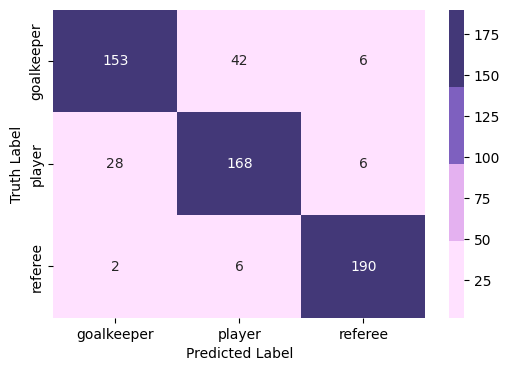

In [56]:
# Generate a confusion matrix to evaluate the model's classification performance on the test set
# Vẽ ma trận nhầm lẫn (confusion matrix) để phân tích lỗi của mô hình trên tập validation
cm = confusion_matrix(test_gen.classes, y_pred_MobileNetV2)
labels = list(class_dict.keys())
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap=color, xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted Label')
plt.ylabel('Truth Label')
plt.show()

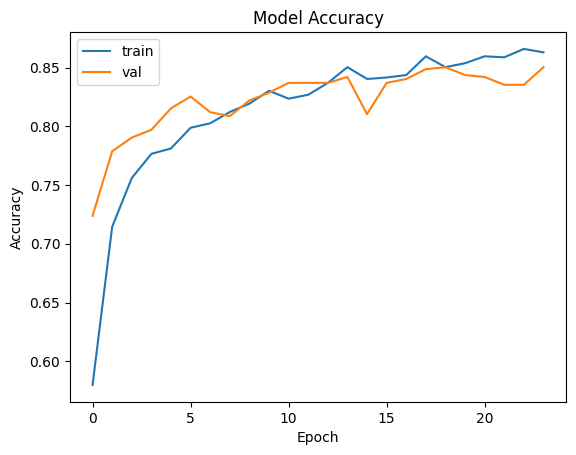

In [57]:
# Plot the training and validation accuracy over epochs
# Vẽ biểu đồ Accuracy (độ chính xác) của mô hình trong quá trình huấn luyện (theo epoch)
plt.plot(history_PretrainedMobileNetV2.history['accuracy'])
plt.plot(history_PretrainedMobileNetV2.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['train', 'val'], loc='upper left')

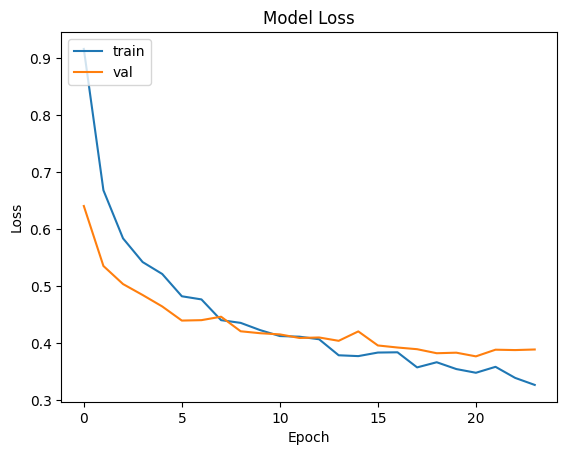

In [58]:
# Plot the training and validation loss over epochs
# Vẽ biểu đồ Loss (hàm mất mát) của mô hình trong quá trình huấn luyện (theo epoch)
plt.plot(history_PretrainedMobileNetV2.history['loss'])
plt.plot(history_PretrainedMobileNetV2.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['train', 'val'], loc='upper left')

In [59]:
# Hàm dự đoán nhãn cho một ảnh đầu vào bằng mô hình Model, đồng thời hiển thị ảnh và biểu đồ xác suất của từng lớp
def predictMobileNetV2(img_path):    
    label = list(class_dict.keys())
    plt.figure(figsize=(8, 6))
    
    #img = Image.open(img_path)
    # Mở ảnh và chuyển sang RGB (loại bỏ kênh Alpha nếu có)
    img = Image.open(img_path).convert('RGB')
    
    resized_img = img.resize((IMAGE_SIZE[0], IMAGE_SIZE[1]))
    img = np.asarray(resized_img)
    img = np.expand_dims(img, axis=0)
    img = img / 255
    predictions = modelPretrainedMobileNetV2.predict(img)
    probs = list(predictions[0])
    labels = label
    plt.subplot(2, 1, 1)
    plt.imshow(resized_img)
    plt.subplot(2, 1, 2)
    bars = plt.barh(labels, probs)
    plt.xlabel('Probability', fontsize=15)
    ax = plt.gca()
    ax.bar_label(bars, fmt = '%.2f')    
    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


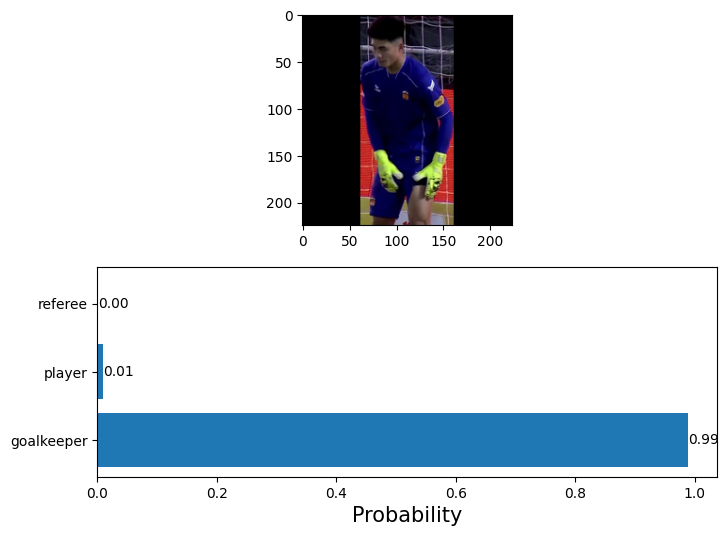

In [60]:
predictMobileNetV2(pred_dir + '/goalkeeper/21.HAGLVHN7_f0819_p00.jpg')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step


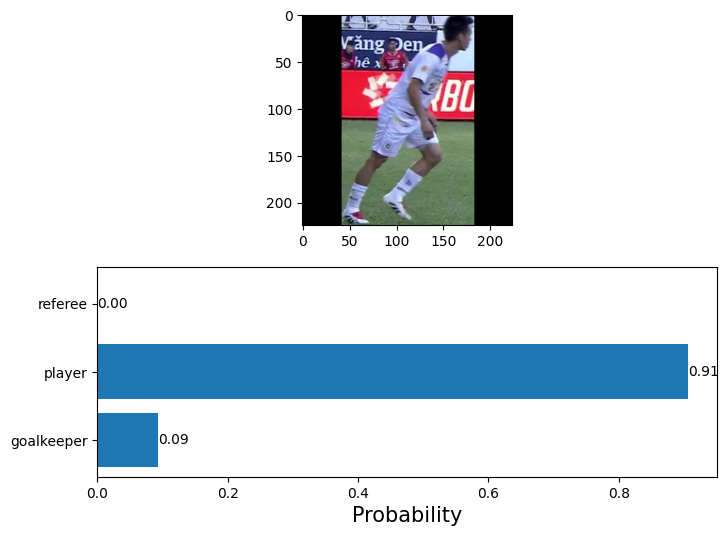

In [61]:
predictMobileNetV2(pred_dir + '/player/21.HAGLVHN7_f0194_p00.jpg')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step


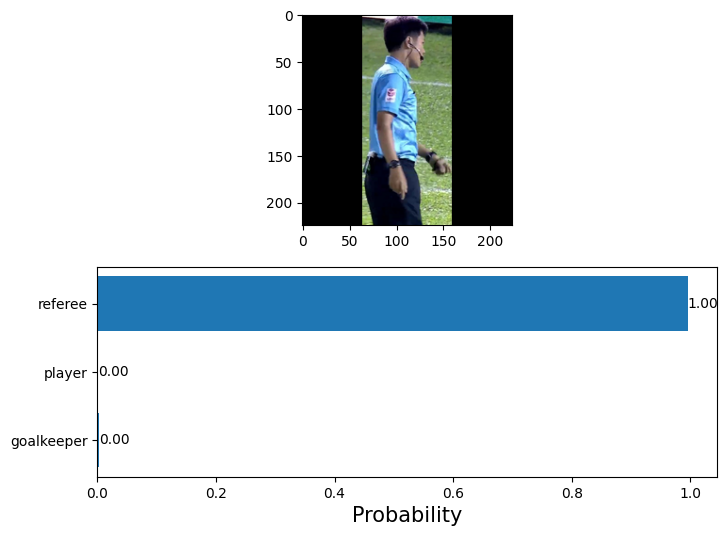

In [62]:
predictMobileNetV2(pred_dir + '/referee/21.HAGLVHN7_f0570_p00.jpg')

<h2 style="background-color: #367E7F; color: white; padding: 15px; text-align: center; font-size: 20px; border-radius: 6px; font-weight: bold;">
    7.2 Using ResNet50 (Pretrained)
</h2>

In [63]:
from tensorflow.keras.applications import ResNet50

# Load pretrained ResNet50 without top layer
base_model_ResNet50 = ResNet50(weights='imagenet', include_top=False, input_shape=(IMAGE_SIZE[0], IMAGE_SIZE[1], 3))
base_model_ResNet50.trainable = False  # Freeze ResNet50 để dùng như feature extractor

# Build classification head
modelPretrainedResNet50 = Sequential([
    base_model_ResNet50,
    GlobalAveragePooling2D(),
    #BatchNormalization(),             # Giúp huấn luyện ổn định hơn
    Dense(256, activation='relu'),
    Dropout(0.4),
    Dense(3, activation='softmax')
])

# Compile model
modelPretrainedResNet50.compile(
    optimizer=Adamax(learning_rate=0.0005),  # Có thể giảm learning rate so với MobileNetV2
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [64]:
# Train the ResNet50-based model
# Huấn luyện mô hình bằng cách sử dụng dữ liệu huấn luyện (train_gen) và kiểm định với dữ liệu validation (valid_gen)
history_PretrainedResNet50 = modelPretrainedResNet50.fit(
    train_gen, 
    validation_data=valid_gen, 
    epochs=50,
    callbacks = [
        EarlyStopping(monitor='val_accuracy', mode='max', patience = 5, restore_best_weights = True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1, min_lr=1e-6)
    ],    
    verbose=1,   
)

# Lấy val_acc tốt nhất trong lịch sử huấn luyện
history_data = history_PretrainedResNet50.history    
# Tìm chỉ số epoch có val_accuracy cao nhất
val_index = history_data['val_accuracy'].index(max(history_data['val_accuracy']))    
# Lấy các giá trị tương ứng tại epoch đó
val_acc = history_data['val_accuracy'][val_index]
corresponding_train_acc = history_data['accuracy'][val_index]
epoch = val_index + 1  # Epoch bắt đầu từ 1    
print(f"Best val_accuracy: {val_acc:.4f}, train accuracy: {corresponding_train_acc:.4f}, epoch: {epoch}")

Epoch 1/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 57s 546ms/step - accuracy: 0.3521 - loss: 1.2569 - val_accuracy: 0.3710 - val_loss: 1.0856 - learning_rate: 5.0000e-04
Epoch 2/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 34s 418ms/step - accuracy: 0.3338 - loss: 1.1575 - val_accuracy: 0.4043 - val_loss: 1.0718 - learning_rate: 5.0000e-04
Epoch 3/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 35s 419ms/step - accuracy: 0.3536 - loss: 1.1136 - val_accuracy: 0.3943 - val_loss: 1.0706 - learning_rate: 5.0000e-04
Epoch 4/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 34s 417ms/step - accuracy: 0.3886 - loss: 1.0871 - val_accuracy: 0.4243 - val_loss: 1.0673 - learning_rate: 5.0000e-04
Epoch 5/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 35s 420ms/step - accuracy: 0.3875 - loss: 1.0906 - val_accuracy: 0.4326 - val_loss: 1.0680 - learning_rate: 5.0000e-04
Epoch 6/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 33s 408ms/step - accuracy: 0.3936 - loss: 1.0795 - val_accuracy: 0.4210 - val_loss: 1.0638 - learning_rate: 5.0000e-04
Epoch 7/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 34s 411ms/step - acc

In [65]:
# Evaluate the ResNet50-based model on training, validation, and test datasets
# Đánh giá mô hình trên từng tập dữ liệu (train, valid, test) bằng cách tính loss và accuracy
print(modelPretrainedResNet50.evaluate(train_gen))
print(modelPretrainedResNet50.evaluate(valid_gen))
print(modelPretrainedResNet50.evaluate(test_gen))

75/75 ━━━━━━━━━━━━━━━━━━━━ 33s 442ms/step - accuracy: 0.4026 - loss: 1.0757
[1.0697343349456787, 0.4264150857925415]
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 115ms/step - accuracy: 0.3836 - loss: 1.0750
[1.0584708452224731, 0.46422627568244934]
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 97ms/step - accuracy: 0.3836 - loss: 1.0750
[1.0584708452224731, 0.46422627568244934]


In [66]:
# Generate predictions using the trained ResNet50-based model
preds_ResNet50 = modelPretrainedResNet50.predict(test_gen)
y_pred_ResNet50 = np.argmax(preds_ResNet50, axis=1)

19/19 ━━━━━━━━━━━━━━━━━━━━ 10s 347ms/step


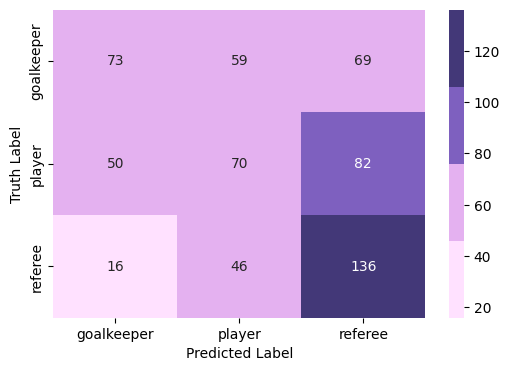

In [67]:
# Generate a confusion matrix to evaluate the model's classification performance on the test set
# Vẽ ma trận nhầm lẫn (confusion matrix) để phân tích lỗi của mô hình trên tập validation
cm = confusion_matrix(test_gen.classes, y_pred_ResNet50)
labels = list(class_dict.keys())
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap=color, xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted Label')
plt.ylabel('Truth Label')
plt.show()

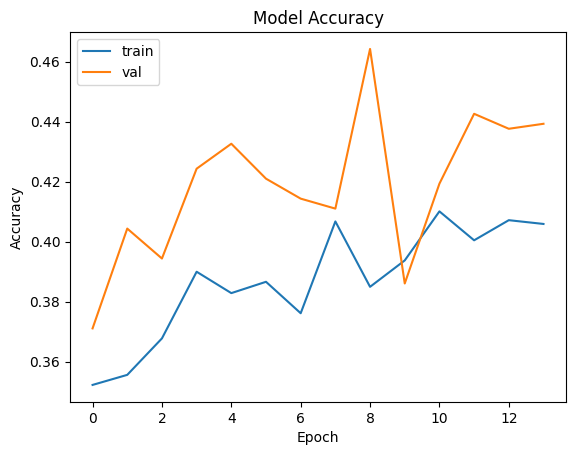

In [68]:
# Plot the training and validation accuracy over epochs
# Vẽ biểu đồ Accuracy (độ chính xác) của mô hình trong quá trình huấn luyện (theo epoch)
plt.plot(history_PretrainedResNet50.history['accuracy'])
plt.plot(history_PretrainedResNet50.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['train', 'val'], loc='upper left')

<h2 style="background-color: #367E7F; color: white; padding: 15px; text-align: center; font-size: 20px; border-radius: 6px; font-weight: bold;">
    7.3 Using EfficientNetB3 (Pretrained)
</h2>

<div style="color: #595959; padding: 15px; font-size: 16px; border: 1px solid #367E7F; border-radius: 6px">
    Load the pre-trained EfficientNetB3 model for feature extraction. The previous model without pretraining had weak performance, so I had to use a pre-trained model to improve accuracy and stability.
</div>

In [69]:
base_model_EfficientNetB3 = tf.keras.applications.EfficientNetB3(
    weights="imagenet",
    include_top=False,    
    input_shape=(IMAGE_SIZE[0],IMAGE_SIZE[1],3)    
)
base_model_EfficientNetB3.trainable = False  # Đóng băng trọng số của MobileNetV2 để dùng như feature extractor

modelPretrainedEfficientNetB3 = Sequential([
    base_model_EfficientNetB3,    
    GlobalAveragePooling2D(),
    Dense(256, activation='relu'),
    Dense(256, activation='relu'),
    Dropout(0.4),
    Dense(3, activation='softmax')
])
modelPretrainedEfficientNetB3.compile(optimizer=Adamax(learning_rate=0.0003), loss='categorical_crossentropy', metrics=['accuracy'])

43941136/43941136 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [70]:
# Train the EfficientNetB3-based model
history_EfficientNetB3 = modelPretrainedEfficientNetB3.fit(
    train_gen,
    validation_data=valid_gen, 
    epochs=50,     
    callbacks = [
        EarlyStopping(monitor='val_accuracy', mode='max', patience = 5, restore_best_weights = True),
        #reduce_lr,  # Giảm learning rate khi val_loss không giảm        
    ],    
    verbose=1,
)

# Lấy val_acc tốt nhất trong lịch sử huấn luyện
history_data = history_EfficientNetB3.history    
# Tìm chỉ số epoch có val_accuracy cao nhất
val_index = history_data['val_accuracy'].index(max(history_data['val_accuracy']))    
# Lấy các giá trị tương ứng tại epoch đó
val_acc = history_data['val_accuracy'][val_index]
corresponding_train_acc = history_data['accuracy'][val_index]
epoch = val_index + 1  # Epoch bắt đầu từ 1    
print(f"Best val_accuracy: {val_acc:.4f}, train accuracy: {corresponding_train_acc:.4f}, epoch: {epoch}")

Epoch 1/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 105s 828ms/step - accuracy: 0.3338 - loss: 1.1128 - val_accuracy: 0.3344 - val_loss: 1.1000
Epoch 2/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 34s 416ms/step - accuracy: 0.3458 - loss: 1.1052 - val_accuracy: 0.3344 - val_loss: 1.0990
Epoch 3/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 35s 420ms/step - accuracy: 0.3423 - loss: 1.1004 - val_accuracy: 0.3344 - val_loss: 1.0987
Epoch 4/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 34s 419ms/step - accuracy: 0.3352 - loss: 1.1011 - val_accuracy: 0.3361 - val_loss: 1.0989
Epoch 5/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 34s 418ms/step - accuracy: 0.3194 - loss: 1.1004 - val_accuracy: 0.3344 - val_loss: 1.0986
Epoch 6/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 34s 415ms/step - accuracy: 0.3424 - loss: 1.1011 - val_accuracy: 0.3361 - val_loss: 1.0996
Epoch 7/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 34s 413ms/step - accuracy: 0.3360 - loss: 1.1017 - val_accuracy: 0.3361 - val_loss: 1.0986
Epoch 8/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 34s 419ms/step - accuracy: 0.3475 - loss: 1.0994 - val_acc

In [71]:
# Evaluate the EfficientNetB3-based model on training, validation, and test datasets
print(modelPretrainedEfficientNetB3.evaluate(train_gen))
print(modelPretrainedEfficientNetB3.evaluate(valid_gen))
print(modelPretrainedEfficientNetB3.evaluate(test_gen))

75/75 ━━━━━━━━━━━━━━━━━━━━ 36s 475ms/step - accuracy: 0.3330 - loss: 1.0993
[1.0993062257766724, 0.33165618777275085]
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 103ms/step - accuracy: 0.2522 - loss: 1.0962
[1.0988764762878418, 0.33610647916793823]
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 102ms/step - accuracy: 0.2522 - loss: 1.0962
[1.0988764762878418, 0.33610647916793823]


In [72]:
# Saving the trained model to a file
modelPretrainedEfficientNetB3.save('Model_EfficientNetB3_Football_90%.h5')

In [73]:
# Generate predictions using the trained EfficientNetB3 model
preds_EfficientNetB3 = modelPretrainedEfficientNetB3.predict(test_gen)
y_pred_EfficientNetB3 = np.argmax(preds_EfficientNetB3, axis=1)

19/19 ━━━━━━━━━━━━━━━━━━━━ 21s 647ms/step


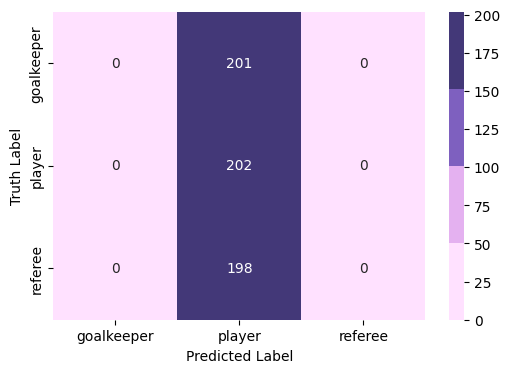

In [74]:
# Generate a confusion matrix to evaluate the model's classification performance on the test set
cm = confusion_matrix(test_gen.classes, y_pred_EfficientNetB3)
labels = list(class_dict.keys())
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap=color, xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted Label')
plt.ylabel('Truth Label')
plt.show()

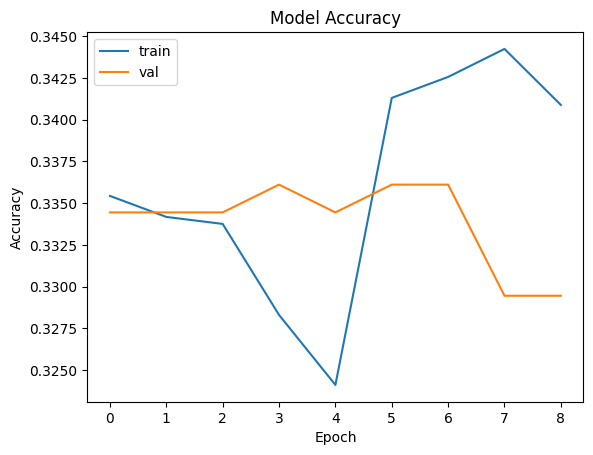

In [75]:
# Plot the training and validation accuracy over epochs
plt.plot(history_EfficientNetB3.history['accuracy'])
plt.plot(history_EfficientNetB3.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['train', 'val'], loc='upper left')

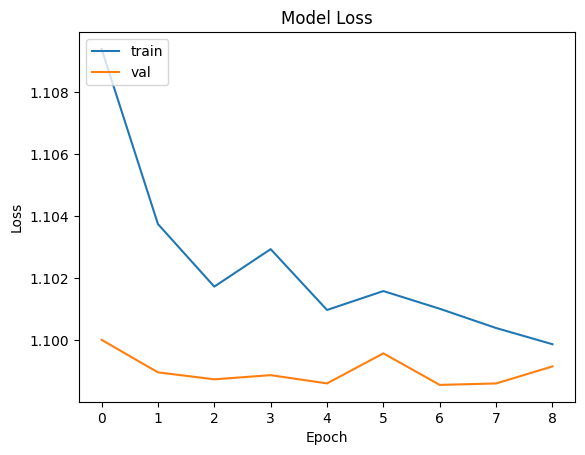

In [76]:
# Plot the training and validation loss over epochs
plt.plot(history_EfficientNetB3.history['loss'])
plt.plot(history_EfficientNetB3.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['train', 'val'], loc='upper left')

In [77]:
# Function to predict the class of an input image and visualize the results
# Hàm dự đoán nhãn cho một ảnh đầu vào bằng mô hình Model, đồng thời hiển thị ảnh và biểu đồ xác suất của từng lớp
def predictEfficientNetB3(img_path):    
    label = list(class_dict.keys())
    plt.figure(figsize=(8, 6))
    
    #img = Image.open(img_path)
    # Mở ảnh và chuyển sang RGB (loại bỏ kênh Alpha nếu có)
    img = Image.open(img_path).convert('RGB')
    
    resized_img = img.resize((IMAGE_SIZE[0], IMAGE_SIZE[1]))
    img = np.asarray(resized_img)
    img = np.expand_dims(img, axis=0)
    img = img / 255
    predictions = modelPretrainedEfficientNetB3.predict(img)
    probs = list(predictions[0])
    labels = label
    plt.subplot(2, 1, 1)
    plt.imshow(resized_img)
    plt.subplot(2, 1, 2)
    bars = plt.barh(labels, probs)
    plt.xlabel('Probability', fontsize=15)
    ax = plt.gca()
    ax.bar_label(bars, fmt = '%.2f')
    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 10s 10s/step


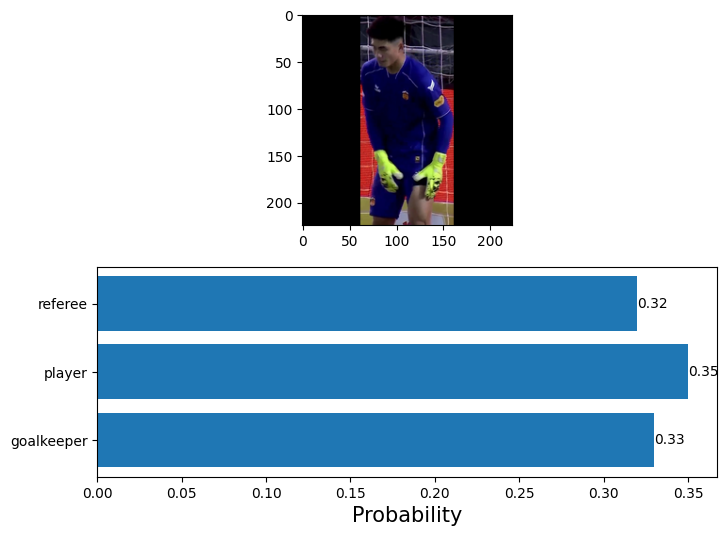

In [78]:
predictEfficientNetB3(pred_dir + '/goalkeeper/21.HAGLVHN7_f0819_p00.jpg')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step


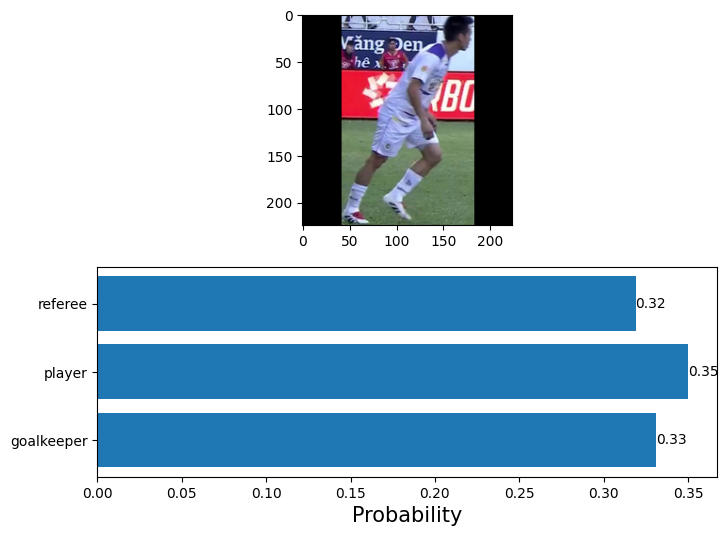

In [79]:
predictEfficientNetB3(pred_dir + '/player/21.HAGLVHN7_f0194_p00.jpg')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step


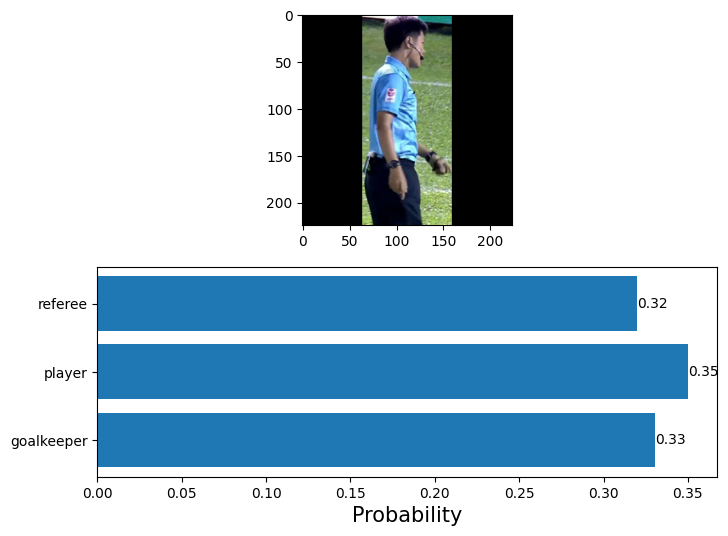

In [80]:
predictEfficientNetB3(pred_dir + '/referee/21.HAGLVHN7_f0570_p00.jpg')

<h2 style="background-color: #367E7F; color: white; padding: 15px; text-align: center; font-size: 20px; border-radius: 6px; font-weight: bold;">
    7.4 Using VGG16 (Pretrained)
</h2>

In [81]:
# Load the pre-trained VGG16 model on ImageNet for feature extraction
base_model_VGG16  = keras.applications.VGG16(
    weights="imagenet",
    include_top=False,    
    input_shape=(IMAGE_SIZE[0],IMAGE_SIZE[1],3)    
)
base_model_VGG16.trainable = False  # Đóng băng trọng số của MobileNetV2 để dùng như feature extractor

modelPretrainedVGG16= Sequential([
    base_model_VGG16,    
    GlobalAveragePooling2D(),
    #BatchNormalization(),
    Dense(256 , activation='relu'),
    Dense(256 , activation='relu'),
    Dropout(0.4),
    Dense(3, activation='softmax')    
])
modelPretrainedVGG16.compile(optimizer=Adamax(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [82]:
# Train the VGG16-based model on the dataset
history_PretrainedVGG16 = modelPretrainedVGG16.fit(
    train_gen,
    validation_data=valid_gen, 
    epochs=50,
    callbacks = [
        EarlyStopping(monitor='val_accuracy', mode='max', patience = 5, restore_best_weights = True),
        #reduce_lr,  # Giảm learning rate khi val_loss không giảm        
    ],    
    verbose=1
)

# Lấy val_acc tốt nhất trong lịch sử huấn luyện
history_data = history_PretrainedVGG16.history    
# Tìm chỉ số epoch có val_accuracy cao nhất
val_index = history_data['val_accuracy'].index(max(history_data['val_accuracy']))    
# Lấy các giá trị tương ứng tại epoch đó
val_acc = history_data['val_accuracy'][val_index]
corresponding_train_acc = history_data['accuracy'][val_index]
epoch = val_index + 1  # Epoch bắt đầu từ 1    
print(f"Best val_accuracy: {val_acc:.4f}, train accuracy: {corresponding_train_acc:.4f}, epoch: {epoch}")

Epoch 1/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 53s 535ms/step - accuracy: 0.3926 - loss: 1.1015 - val_accuracy: 0.5607 - val_loss: 0.9774
Epoch 2/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 34s 414ms/step - accuracy: 0.5304 - loss: 0.9712 - val_accuracy: 0.6489 - val_loss: 0.8822
Epoch 3/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 34s 410ms/step - accuracy: 0.6325 - loss: 0.8579 - val_accuracy: 0.7188 - val_loss: 0.7767
Epoch 4/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 34s 415ms/step - accuracy: 0.6534 - loss: 0.7951 - val_accuracy: 0.7121 - val_loss: 0.7125
Epoch 5/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 34s 407ms/step - accuracy: 0.6907 - loss: 0.7238 - val_accuracy: 0.7205 - val_loss: 0.6670
Epoch 6/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 34s 416ms/step - accuracy: 0.7179 - loss: 0.6803 - val_accuracy: 0.7488 - val_loss: 0.6177
Epoch 7/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 35s 421ms/step - accuracy: 0.7386 - loss: 0.6133 - val_accuracy: 0.7504 - val_loss: 0.5935
Epoch 8/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 34s 410ms/step - accuracy: 0.7303 - loss: 0.6181 - val_accu

In [83]:
# Evaluate the VGG16-based model on different datasets
print(modelPretrainedVGG16.evaluate(train_gen))
print(modelPretrainedVGG16.evaluate(valid_gen))
print(modelPretrainedVGG16.evaluate(test_gen))

75/75 ━━━━━━━━━━━━━━━━━━━━ 32s 426ms/step - accuracy: 0.7884 - loss: 0.5164
[0.5176025032997131, 0.7857442498207092]
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 105ms/step - accuracy: 0.7261 - loss: 0.6279
[0.5222839713096619, 0.7870216369628906]
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 94ms/step - accuracy: 0.7261 - loss: 0.6279
[0.5222839713096619, 0.7870216369628906]


In [84]:
# Save the trained VGG16-based model to a file
modelPretrainedVGG16.save('Model_VGG16_Football_90%.h5')

In [85]:
# Generate predictions using the trained VGG16-based model
preds_VGG16 = modelPretrainedVGG16.predict(test_gen)
y_pred_VGG16 = np.argmax(preds_VGG16, axis=1)

19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 125ms/step


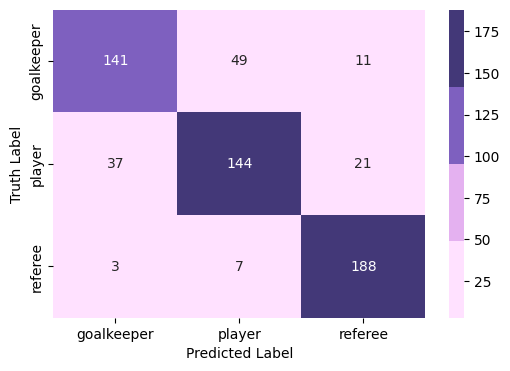

In [86]:
# Generate the confusion matrix for the VGG16 model predictions
cm = confusion_matrix(test_gen.classes, y_pred_VGG16)
labels = list(class_dict.keys())
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap=color, xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted Label')
plt.ylabel('Truth Label')
plt.show()

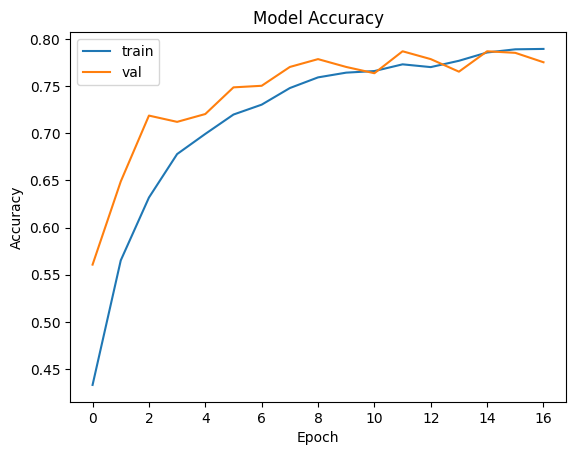

In [87]:
# Plot training and validation accuracy over epochs for the VGG16 model
plt.plot(history_PretrainedVGG16.history['accuracy'])
plt.plot(history_PretrainedVGG16.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['train', 'val'], loc='upper left')

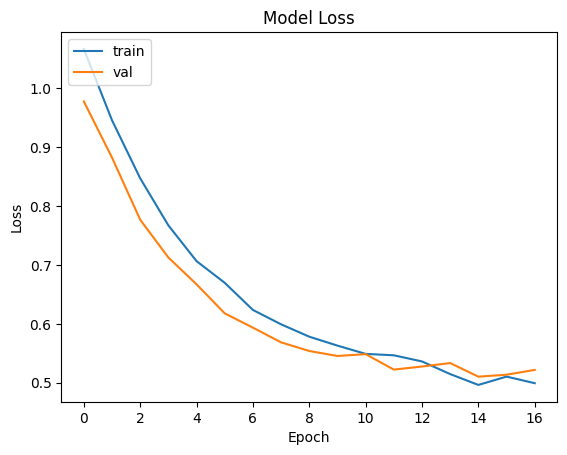

In [88]:
# Plot training and validation loss over epochs for the VGG16 model
plt.plot(history_PretrainedVGG16.history['loss'])
plt.plot(history_PretrainedVGG16.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['train', 'val'], loc='upper left')

In [89]:
# Function to predict the class of an input image and visualize the results
# Hàm dự đoán nhãn cho một ảnh đầu vào bằng mô hình Model, đồng thời hiển thị ảnh và biểu đồ xác suất của từng lớp
def predictVGG16(img_path):    
    label = list(class_dict.keys())
    plt.figure(figsize=(8, 6))
    
    #img = Image.open(img_path)
    # Mở ảnh và chuyển sang RGB (loại bỏ kênh Alpha nếu có)
    img = Image.open(img_path).convert('RGB')
    
    resized_img = img.resize((IMAGE_SIZE[0], IMAGE_SIZE[1]))
    img = np.asarray(resized_img)
    img = np.expand_dims(img, axis=0)
    img = img / 255
    predictions = modelPretrainedVGG16.predict(img)
    probs = list(predictions[0])
    labels = label
    plt.subplot(2, 1, 1)
    plt.imshow(resized_img)
    plt.subplot(2, 1, 2)
    bars = plt.barh(labels, probs)
    plt.xlabel('Probability', fontsize=15)
    ax = plt.gca()
    ax.bar_label(bars, fmt = '%.2f')
    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


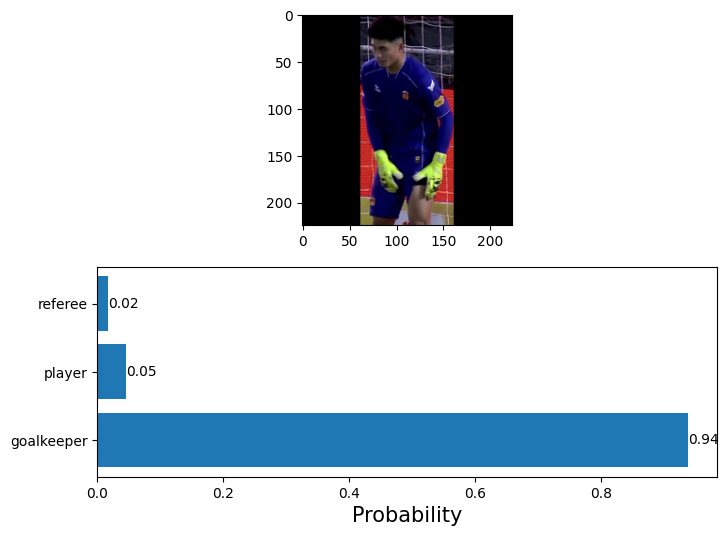

In [90]:
predictVGG16(pred_dir + '/goalkeeper/21.HAGLVHN7_f0819_p00.jpg')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


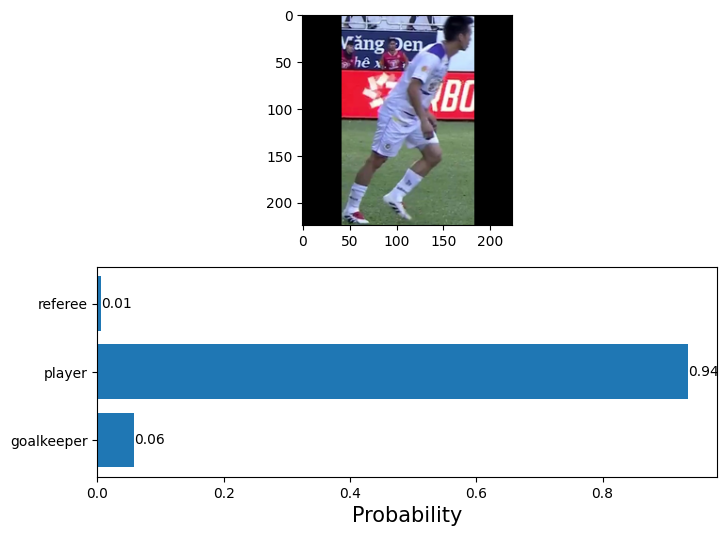

In [91]:
predictVGG16(pred_dir + '/player/21.HAGLVHN7_f0194_p00.jpg')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step


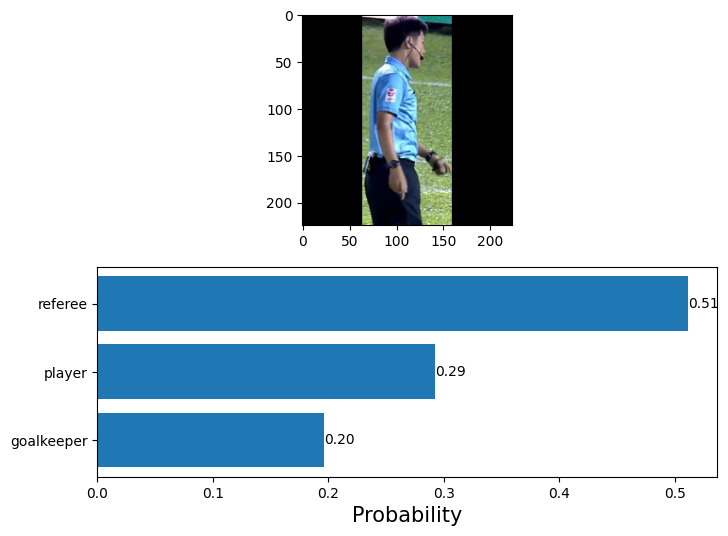

In [92]:
predictVGG16(pred_dir + '/referee/21.HAGLVHN7_f0570_p00.jpg')

<h2 style="background-color: #367E7F; color: white; padding: 15px; text-align: center; font-size: 20px; border-radius: 6px; font-weight: bold;">
    7.5 Using YOLOv8n (Pretrained)
</h2>

In [93]:
# Lấy đường dẫn thư mục hiện tại và gán vào biến HOME
# Biến HOME thường dùng làm gốc để định nghĩa các đường dẫn khác
import os
HOME = os.getcwd()
print(HOME)

/kaggle/working


In [94]:
# Fix lỗi: AttributeError: module 'ray.train._internal.session' has no attribute '_get_session'. Did you mean: 'get_session'?
# Phiên bản YOLOv8 (Ultralytics) đang dùng gọi nhầm một API nội bộ đã thay đổi của Ray gây nên lỗi.
# YOLOv8 không yêu cầu ray để huấn luyện thông thường nên có thể gỡ cài đặt ray.
# Nếu thực sự cần ray, cài phiên bản cũ hơn (ví dụ ray==2.6.3) — phiên bản vẫn còn _get_session:
!pip uninstall -y ray

Found existing installation: ray 2.44.1
Uninstalling ray-2.44.1:
  Successfully uninstalled ray-2.44.1


In [95]:
# Cài đặt phiên bản ổn định cụ thể của YOLOv8 (Ultralytics) (đảm bảo tính tương thích)
!pip install ultralytics==8.2.103 -q

# Kiểm tra môi trường hiện tại xem đã đủ điều kiện để dùng YOLOv8 chưa 
import ultralytics
ultralytics.checks()

Ultralytics YOLOv8.2.103 🚀 Python-3.11.11 torch-2.5.1+cu124 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
Setup complete ✅ (4 CPUs, 31.4 GB RAM, 6281.9/8062.4 GB disk)


In [96]:
import os
import shutil

dataset_path = "/kaggle/input/vleague-lpbank-24-25-v6"
work_dataset_path = HOME + "/dataset"

shutil.rmtree(work_dataset_path, ignore_errors=True)

# Copy toàn bộ dataset vào thư mục làm việc để sửa tên
!cp -r {dataset_path} {work_dataset_path}

# Đổi tên test → val trong thư mục working
os.rename(f"{work_dataset_path}/test", f"{work_dataset_path}/val")

### Training the Custom YOLOv8n-cls
Thực hiện huấn luyện mô hình YOLOv8 trên tập dữ liệu tùy chỉnh, sẵn sàng để đánh giá và dùng cho inference.

Đảm bảo đang ở đúng thư mục gốc (/kaggle/working), để các file kết quả (mô hình, biểu đồ) được lưu vào đúng vị trí.

In [97]:
# Training với YOLOv8n-cls
from ultralytics import YOLO
from IPython.display import display, Image

import shutil
shutil.rmtree(f'{HOME}/runs/classify/train', ignore_errors=True)

# Load YOLOv8n-cls pretrained model
model = YOLO('yolov8n-cls.pt')  # pretrained on ImageNet

# Huấn luyện lại với dữ liệu tùy biến cá nhân
model.train(
    data=work_dataset_path,     # đường dẫn thư mục chứa train/ và val/
    epochs=50,
    imgsz=224,          # Kích thước ảnh (nên là 224x224)
    batch=32,
    lr0=0.0005,         # learning rate ban đầu
    patience=5,         # early stopping
    device=0            # GPU nếu có, nếu không thì device='cpu'
)

100%|██████████| 5.31M/5.31M [00:00<00:00, 114MB/s]


New https://pypi.org/project/ultralytics/8.3.117 available 😃 Update with 'pip install -U ultralytics'
Ultralytics YOLOv8.2.103 🚀 Python-3.11.11 torch-2.5.1+cu124 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
engine/trainer: task=classify, mode=train, model=yolov8n-cls.pt, data=/kaggle/working/dataset, epochs=50, time=None, patience=5, batch=32, imgsz=224, save=True, save_period=-1, cache=False, device=0, workers=8, project=None, name=train, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=Fa

100%|██████████| 6.25M/6.25M [00:00<00:00, 117MB/s]


AMP: checks passed ✅


train: Scanning /kaggle/working/dataset/train... 2385 images, 0 corrupt: 100%|██████████| 2385/2385 [00:00<00:00, 3652.49it/s]

train: New cache created: /kaggle/working/dataset/train.cache



val: Scanning /kaggle/working/dataset/val... 601 images, 0 corrupt: 100%|██████████| 601/601 [00:00<00:00, 1527.64it/s]

val: New cache created: /kaggle/working/dataset/val.cache


optimizer: 'optimizer=auto' found, ignoring 'lr0=0.0005' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: AdamW(lr=0.000714, momentum=0.9) with parameter groups 26 weight(decay=0.0), 27 weight(decay=0.0005), 27 bias(decay=0.0)
TensorBoard: model graph visualization added ✅
Image sizes 224 train, 224 val
Using 4 dataloader workers
Logging results to runs/classify/train
Starting training for 50 epochs...

      Epoch    GPU_mem       loss  Instances       Size


       1/50     0.541G      1.096         32        224:  11%|█         | 8/75 [00:01<00:06, 10.90it/s]

       1/50     0.541G      1.082         32        224:  16%|█▌        | 12/75 [00:01<00:05, 10.54it/s]
100%|██████████| 755k/755k [00:00<00:00, 21.9MB/s]  224:  16%|█▌        | 12/75 [00:01<00:05, 10.54it/s]
               classes   top1_acc   top5_acc: 100%|██████████| 10/10 [00:01<00:00,  9.36it/s]

                   all       0.78          1



      Epoch    GPU_mem       loss  Instances       Size


               classes   top1_acc   top5_acc: 100%|██████████| 10/10 [00:00<00:00, 15.71it/s]

                   all      0.855          1



      Epoch    GPU_mem       loss  Instances       Size


               classes   top1_acc   top5_acc: 100%|██████████| 10/10 [00:00<00:00, 18.87it/s]

                   all      0.894          1



      Epoch    GPU_mem       loss  Instances       Size


               classes   top1_acc   top5_acc: 100%|██████████| 10/10 [00:00<00:00, 15.01it/s]

                   all      0.887          1



      Epoch    GPU_mem       loss  Instances       Size


               classes   top1_acc   top5_acc: 100%|██████████| 10/10 [00:00<00:00, 12.74it/s]

                   all       0.91          1



      Epoch    GPU_mem       loss  Instances       Size


               classes   top1_acc   top5_acc: 100%|██████████| 10/10 [00:00<00:00, 14.43it/s]

                   all       0.94          1



      Epoch    GPU_mem       loss  Instances       Size


               classes   top1_acc   top5_acc: 100%|██████████| 10/10 [00:00<00:00, 13.37it/s]

                   all       0.94          1



      Epoch    GPU_mem       loss  Instances       Size


               classes   top1_acc   top5_acc: 100%|██████████| 10/10 [00:01<00:00,  9.68it/s]

                   all      0.938          1



      Epoch    GPU_mem       loss  Instances       Size


               classes   top1_acc   top5_acc: 100%|██████████| 10/10 [00:00<00:00, 13.62it/s]

                   all       0.94          1



      Epoch    GPU_mem       loss  Instances       Size


      10/50     0.457G     0.1298         17        224: 100%|██████████| 75/75 [00:06<00:00, 10.96it/s]
               classes   top1_acc   top5_acc: 100%|██████████| 10/10 [00:00<00:00, 17.39it/s]

                   all      0.933          1



      Epoch    GPU_mem       loss  Instances       Size


      11/50     0.466G     0.1132         17        224: 100%|██████████| 75/75 [00:06<00:00, 11.10it/s]
               classes   top1_acc   top5_acc: 100%|██████████| 10/10 [00:00<00:00, 12.60it/s]

                   all       0.94          1



      Epoch    GPU_mem       loss  Instances       Size


      12/50     0.457G     0.1151         17        224: 100%|██████████| 75/75 [00:07<00:00, 10.25it/s]
               classes   top1_acc   top5_acc: 100%|██████████| 10/10 [00:00<00:00, 12.70it/s]

                   all      0.958          1



      Epoch    GPU_mem       loss  Instances       Size


      13/50     0.468G    0.09433         17        224: 100%|██████████| 75/75 [00:06<00:00, 10.90it/s]
               classes   top1_acc   top5_acc: 100%|██████████| 10/10 [00:00<00:00, 16.32it/s]

                   all      0.957          1



      Epoch    GPU_mem       loss  Instances       Size


      14/50     0.455G    0.08461         17        224: 100%|██████████| 75/75 [00:06<00:00, 11.29it/s]
               classes   top1_acc   top5_acc: 100%|██████████| 10/10 [00:00<00:00, 16.52it/s]

                   all      0.953          1



      Epoch    GPU_mem       loss  Instances       Size


      15/50     0.466G    0.09969         17        224: 100%|██████████| 75/75 [00:06<00:00, 10.73it/s]
               classes   top1_acc   top5_acc: 100%|██████████| 10/10 [00:01<00:00,  9.55it/s]

                   all      0.938          1



      Epoch    GPU_mem       loss  Instances       Size


      16/50     0.457G     0.0839         17        224: 100%|██████████| 75/75 [00:06<00:00, 11.22it/s]
               classes   top1_acc   top5_acc: 100%|██████████| 10/10 [00:00<00:00, 13.59it/s]

                   all      0.947          1



      Epoch    GPU_mem       loss  Instances       Size


      17/50     0.468G    0.07294         17        224: 100%|██████████| 75/75 [00:06<00:00, 11.30it/s]
               classes   top1_acc   top5_acc: 100%|██████████| 10/10 [00:00<00:00, 14.57it/s]

                   all      0.933          1
EarlyStopping: Training stopped early as no improvement observed in last 5 epochs. Best results observed at epoch 12, best model saved as best.pt.
To update EarlyStopping(patience=5) pass a new patience value, i.e. `patience=300` or use `patience=0` to disable EarlyStopping.



17 epochs completed in 0.044 hours.
Optimizer stripped from runs/classify/train/weights/last.pt, 3.0MB
Optimizer stripped from runs/classify/train/weights/best.pt, 3.0MB

Validating runs/classify/train/weights/best.pt...
Ultralytics YOLOv8.2.103 🚀 Python-3.11.11 torch-2.5.1+cu124 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
YOLOv8n-cls summary (fused): 73 layers, 1,438,723 parameters, 0 gradients, 3.3 GFLOPs
train: /kaggle/working/dataset/train... found 2385 images in 3 classes ✅ 
val: /kaggle/working/dataset/val... found 601 images in 3 classes ✅ 
test: None...


               classes   top1_acc   top5_acc: 100%|██████████| 10/10 [00:00<00:00, 13.76it/s]


                   all      0.957          1
Speed: 0.1ms preprocess, 0.4ms inference, 0.0ms loss, 0.0ms postprocess per image
Results saved to runs/classify/train
Results saved to runs/classify/train


ultralytics.utils.metrics.ClassifyMetrics object with attributes:

confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7f4d11170310>
curves: []
curves_results: []
fitness: 0.9783693850040436
keys: ['metrics/accuracy_top1', 'metrics/accuracy_top5']
results_dict: {'metrics/accuracy_top1': 0.9567387700080872, 'metrics/accuracy_top5': 1.0, 'fitness': 0.9783693850040436}
save_dir: PosixPath('runs/classify/train')
speed: {'preprocess': 0.14998750162997382, 'inference': 0.4083114535161937, 'loss': 0.00033402403261816244, 'postprocess': 0.00030149437623492095}
task: 'classify'
top1: 0.9567387700080872
top5: 1.0

In [98]:
# Hiển thị cấu trúc thư mục train sau khi huấn luyện xong
!ls {HOME}/runs/classify/train

args.yaml					  train_batch2.jpg
confusion_matrix_normalized.png			  val_batch0_labels.jpg
confusion_matrix.png				  val_batch0_pred.jpg
events.out.tfevents.1745682220.b65c379a6464.31.0  val_batch1_labels.jpg
results.csv					  val_batch1_pred.jpg
results.png					  val_batch2_labels.jpg
train_batch0.jpg				  val_batch2_pred.jpg
train_batch1.jpg				  weights


In [99]:
import pandas as pd

# Đường dẫn tới file kết quả
results_path = f'{HOME}/runs/classify/train/results.csv'  # điều chỉnh nếu dùng `name=`

# Đọc kết quả
df = pd.read_csv(results_path)

df.columns = [col.strip() for col in df.columns]
print(df.columns.tolist())

# Tìm chỉ số epoch có val_accuracy cao nhất
val_idx = df['metrics/accuracy_top1'].idxmax()
val_acc = df.loc[val_idx, 'metrics/accuracy_top1']
val_loss = df.loc[val_idx, 'val/loss']
epoch = int(df.loc[val_idx, 'epoch'])

print(f"Best val_accuracy: {val_acc:.4f} tại epoch {epoch}, val_loss: {val_loss:.4f}")

# val_accuracy theo từng epoch
yolo_val_accuracy = df['metrics/accuracy_top1'].tolist()
yolo_val_loss = df['val/loss'].tolist()

['epoch', 'train/loss', 'metrics/accuracy_top1', 'metrics/accuracy_top5', 'val/loss', 'lr/pg0', 'lr/pg1', 'lr/pg2']
Best val_accuracy: 0.9584 tại epoch 12, val_loss: 0.6077


### Hiển thị biểu đồ ma trận nhầm lẫn (confusion matrix)

/kaggle/working


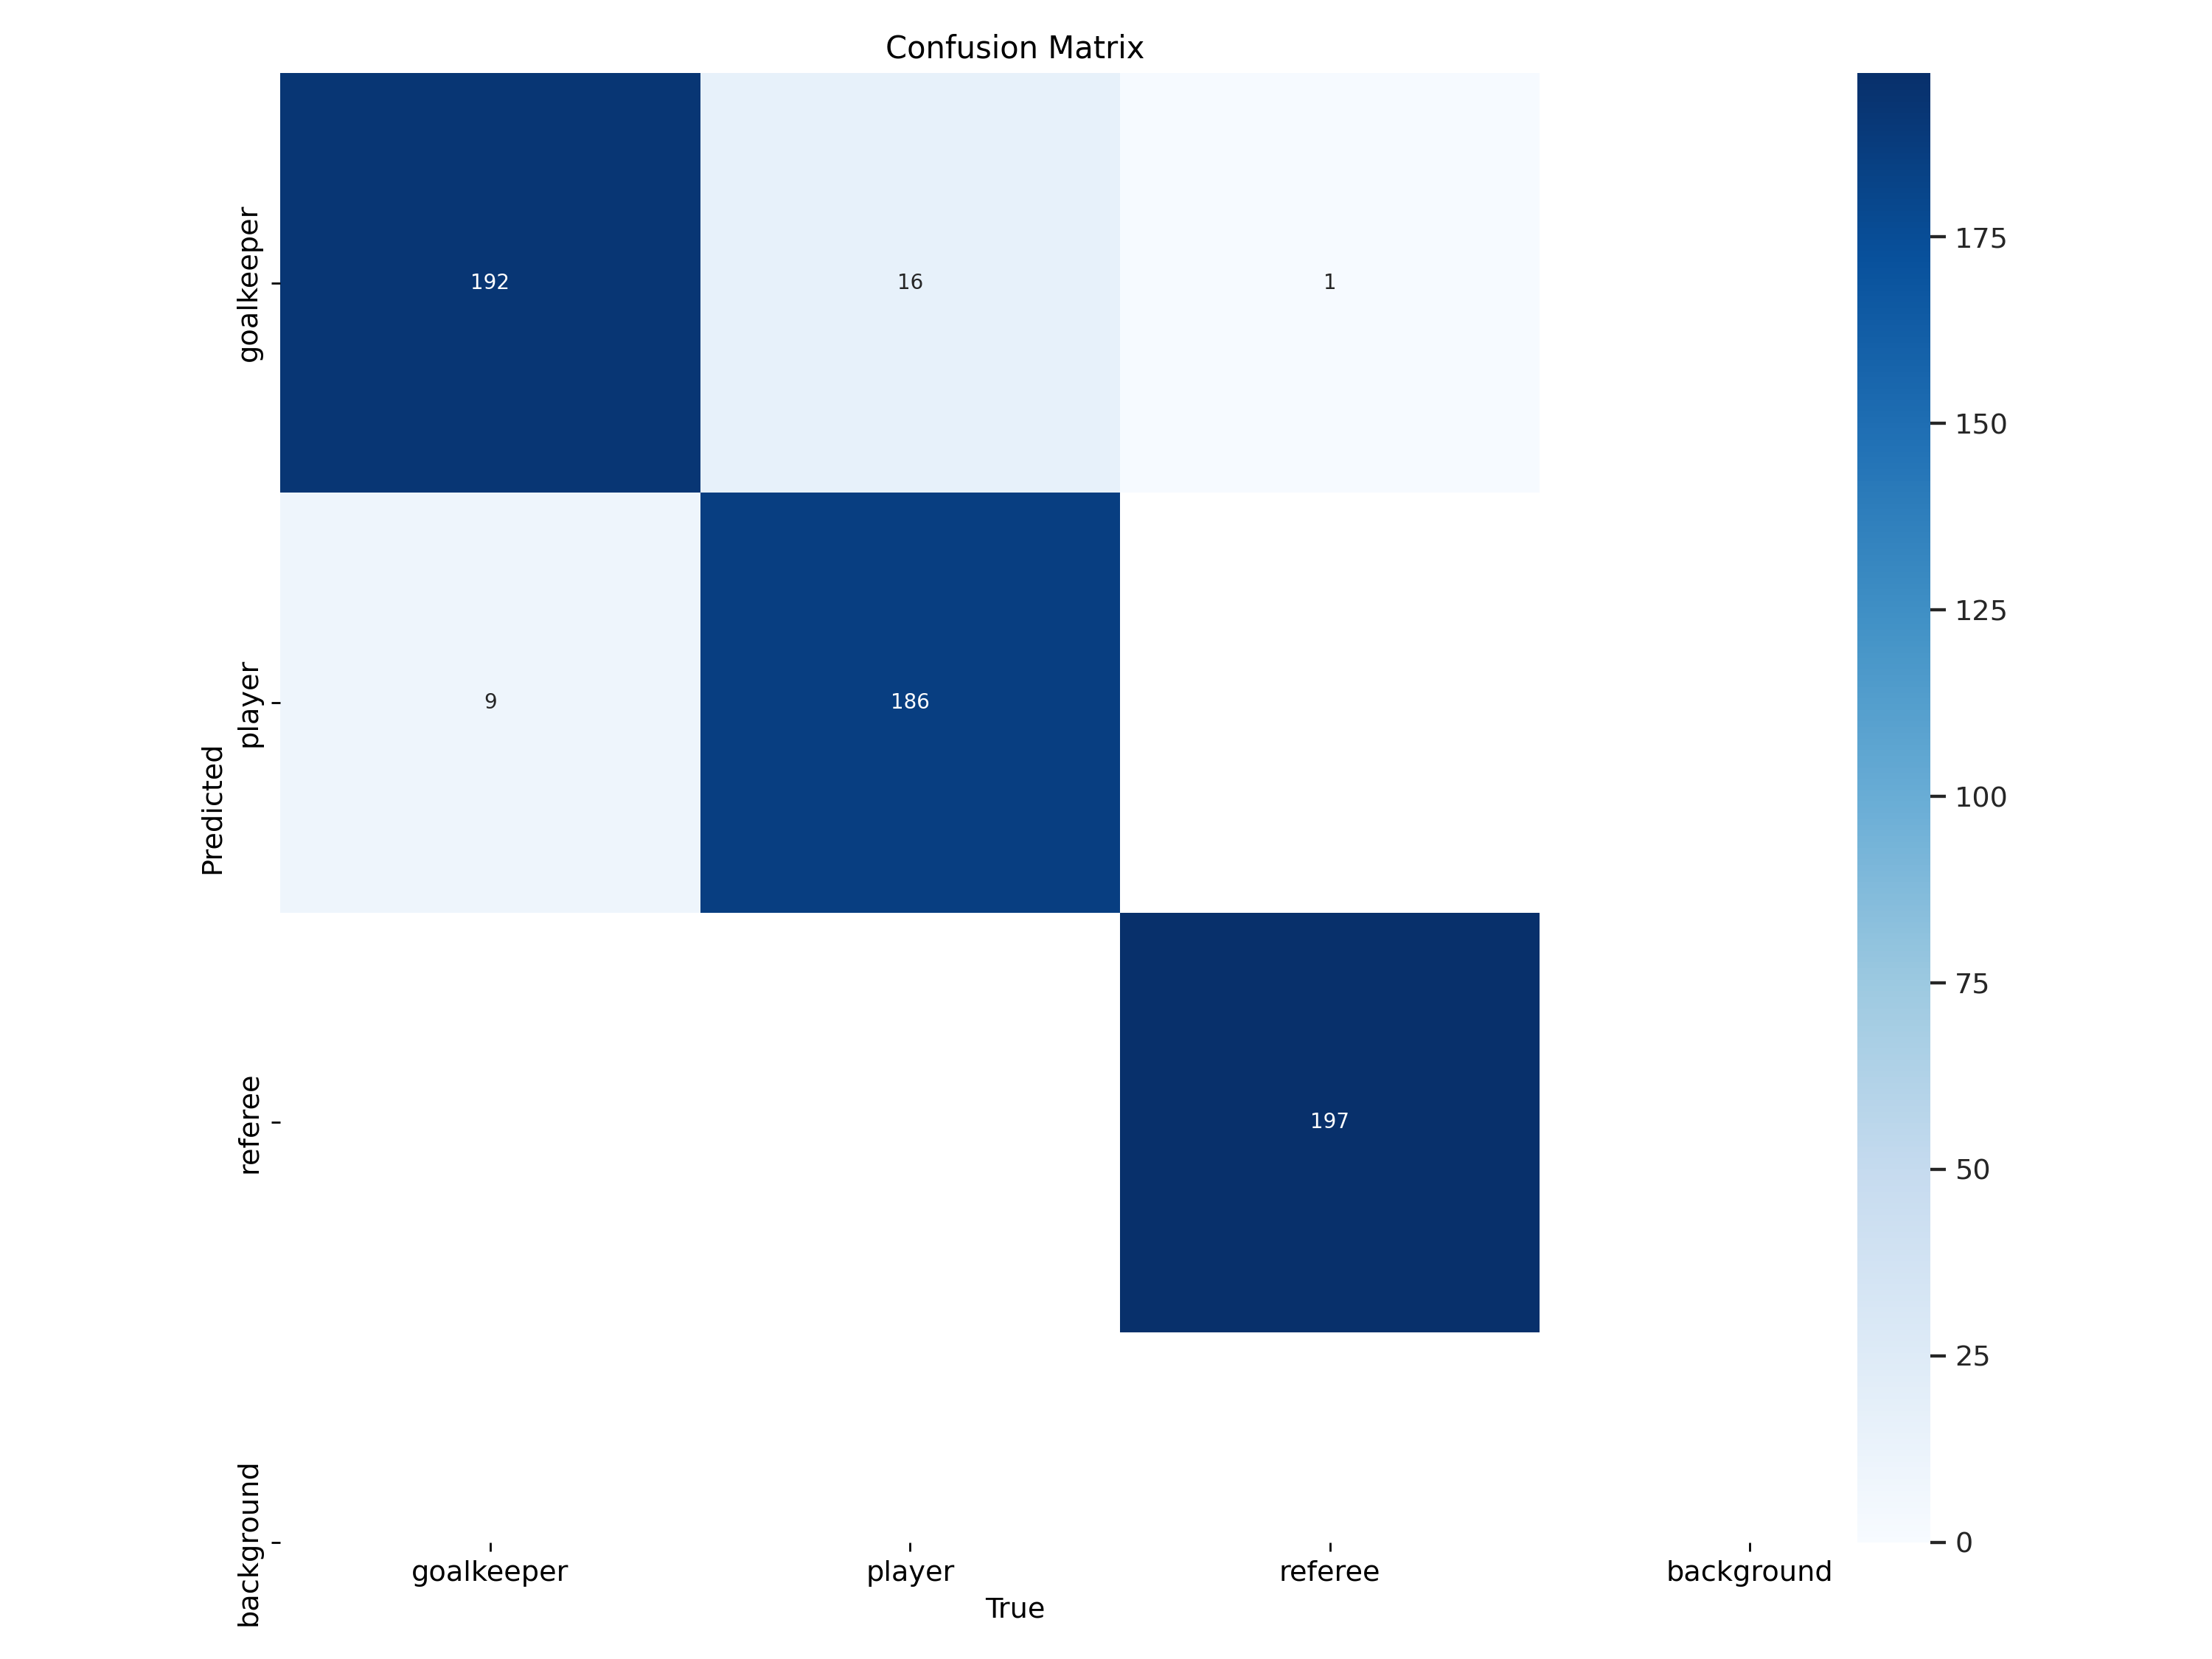

In [100]:
%cd {HOME}
# Ma trận nhầm lẫn
Image(filename=f'{HOME}/runs/classify/train/confusion_matrix.png', width=800)

### Hiển thị biểu đồ tổng hợp kết quả huấn luyện

/kaggle/working


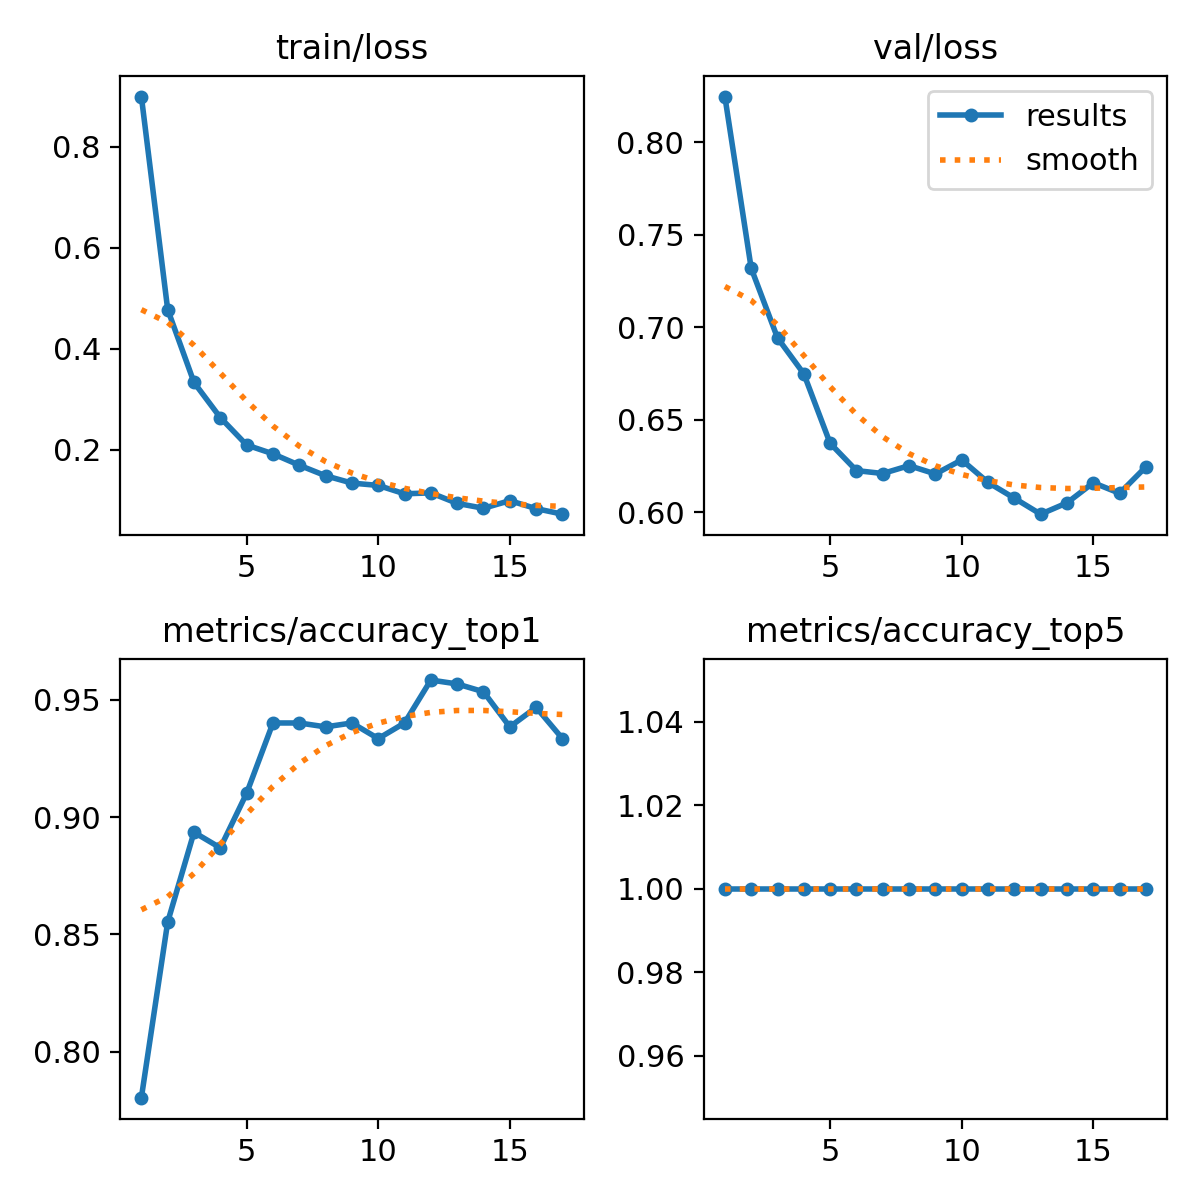

In [101]:
%cd {HOME}
Image(filename=f'{HOME}/runs/classify/train/results.png', width=600)

### Hiển thị ảnh dự đoán trên tập validation

/kaggle/working


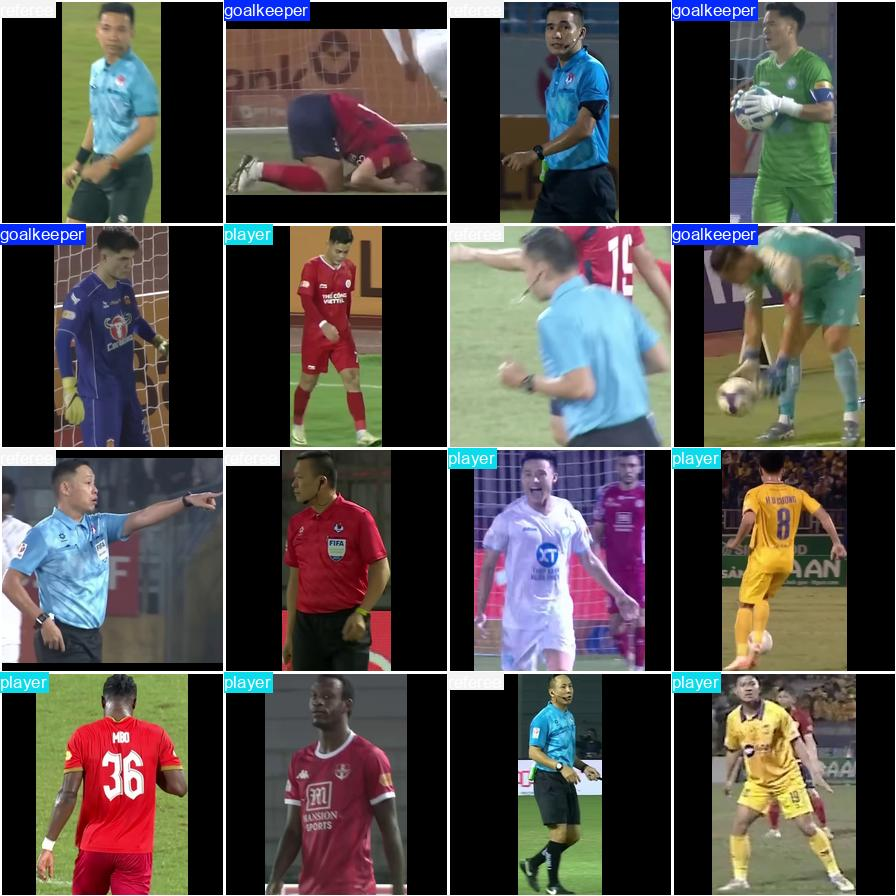

In [102]:
%cd {HOME}
Image(filename=f'{HOME}/runs/classify/train/val_batch0_pred.jpg', width=800)

### Validate YOLOv8n model

In [103]:
import shutil
shutil.rmtree(f'{HOME}/runs/classify/val', ignore_errors=True)

# Đường dẫn mô hình đã huấn luyện và thư mục ảnh test
model_path = f"{HOME}/runs/classify/train/weights/best.pt"

# Load mô hình YOLOv8
model = YOLO(model_path)

# Chạy validation (đánh giá trên tập val)
metrics = model.val() # no arguments needed, dataset and settings remembered

# In kết quả
print(metrics)

# Trích xuất và in các chỉ số
results = metrics.results_dict
val_acc = results.get('metrics/accuracy_top1', None)
val_loss = results.get('val/loss', None)

print(f"✅ Val Accuracy (top-1): {val_acc:.4f}")

Ultralytics YOLOv8.2.103 🚀 Python-3.11.11 torch-2.5.1+cu124 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
YOLOv8n-cls summary (fused): 73 layers, 1,438,723 parameters, 0 gradients, 3.3 GFLOPs
train: /kaggle/working/dataset/train... found 2385 images in 3 classes ✅ 
val: /kaggle/working/dataset/val... found 601 images in 3 classes ✅ 
test: None...


val: Scanning /kaggle/working/dataset/val... 601 images, 0 corrupt: 100%|██████████| 601/601 [00:00<?, ?it/s]
               classes   top1_acc   top5_acc: 100%|██████████| 38/38 [00:01<00:00, 28.59it/s]


                   all      0.958          1
Speed: 0.1ms preprocess, 1.1ms inference, 0.0ms loss, 0.0ms postprocess per image
Results saved to runs/classify/val
ultralytics.utils.metrics.ClassifyMetrics object with attributes:

confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7f500c5f7390>
curves: []
curves_results: []
fitness: 0.9792013168334961
keys: ['metrics/accuracy_top1', 'metrics/accuracy_top5']
results_dict: {'metrics/accuracy_top1': 0.9584026336669922, 'metrics/accuracy_top5': 1.0, 'fitness': 0.9792013168334961}
save_dir: PosixPath('runs/classify/val')
speed: {'preprocess': 0.10921871800985987, 'inference': 1.0972911625257546, 'loss': 0.0010956940357379629, 'postprocess': 0.004768768285157875}
task: 'classify'
top1: 0.9584026336669922
top5: 1.0
✅ Val Accuracy (top-1): 0.9584


In [104]:
# Hiển thị cấu trúc thư mục val sau khi val xong
!ls {HOME}/runs/classify/val

confusion_matrix_normalized.png  val_batch0_pred.jpg	val_batch2_labels.jpg
confusion_matrix.png		 val_batch1_labels.jpg	val_batch2_pred.jpg
val_batch0_labels.jpg		 val_batch1_pred.jpg


/kaggle/working


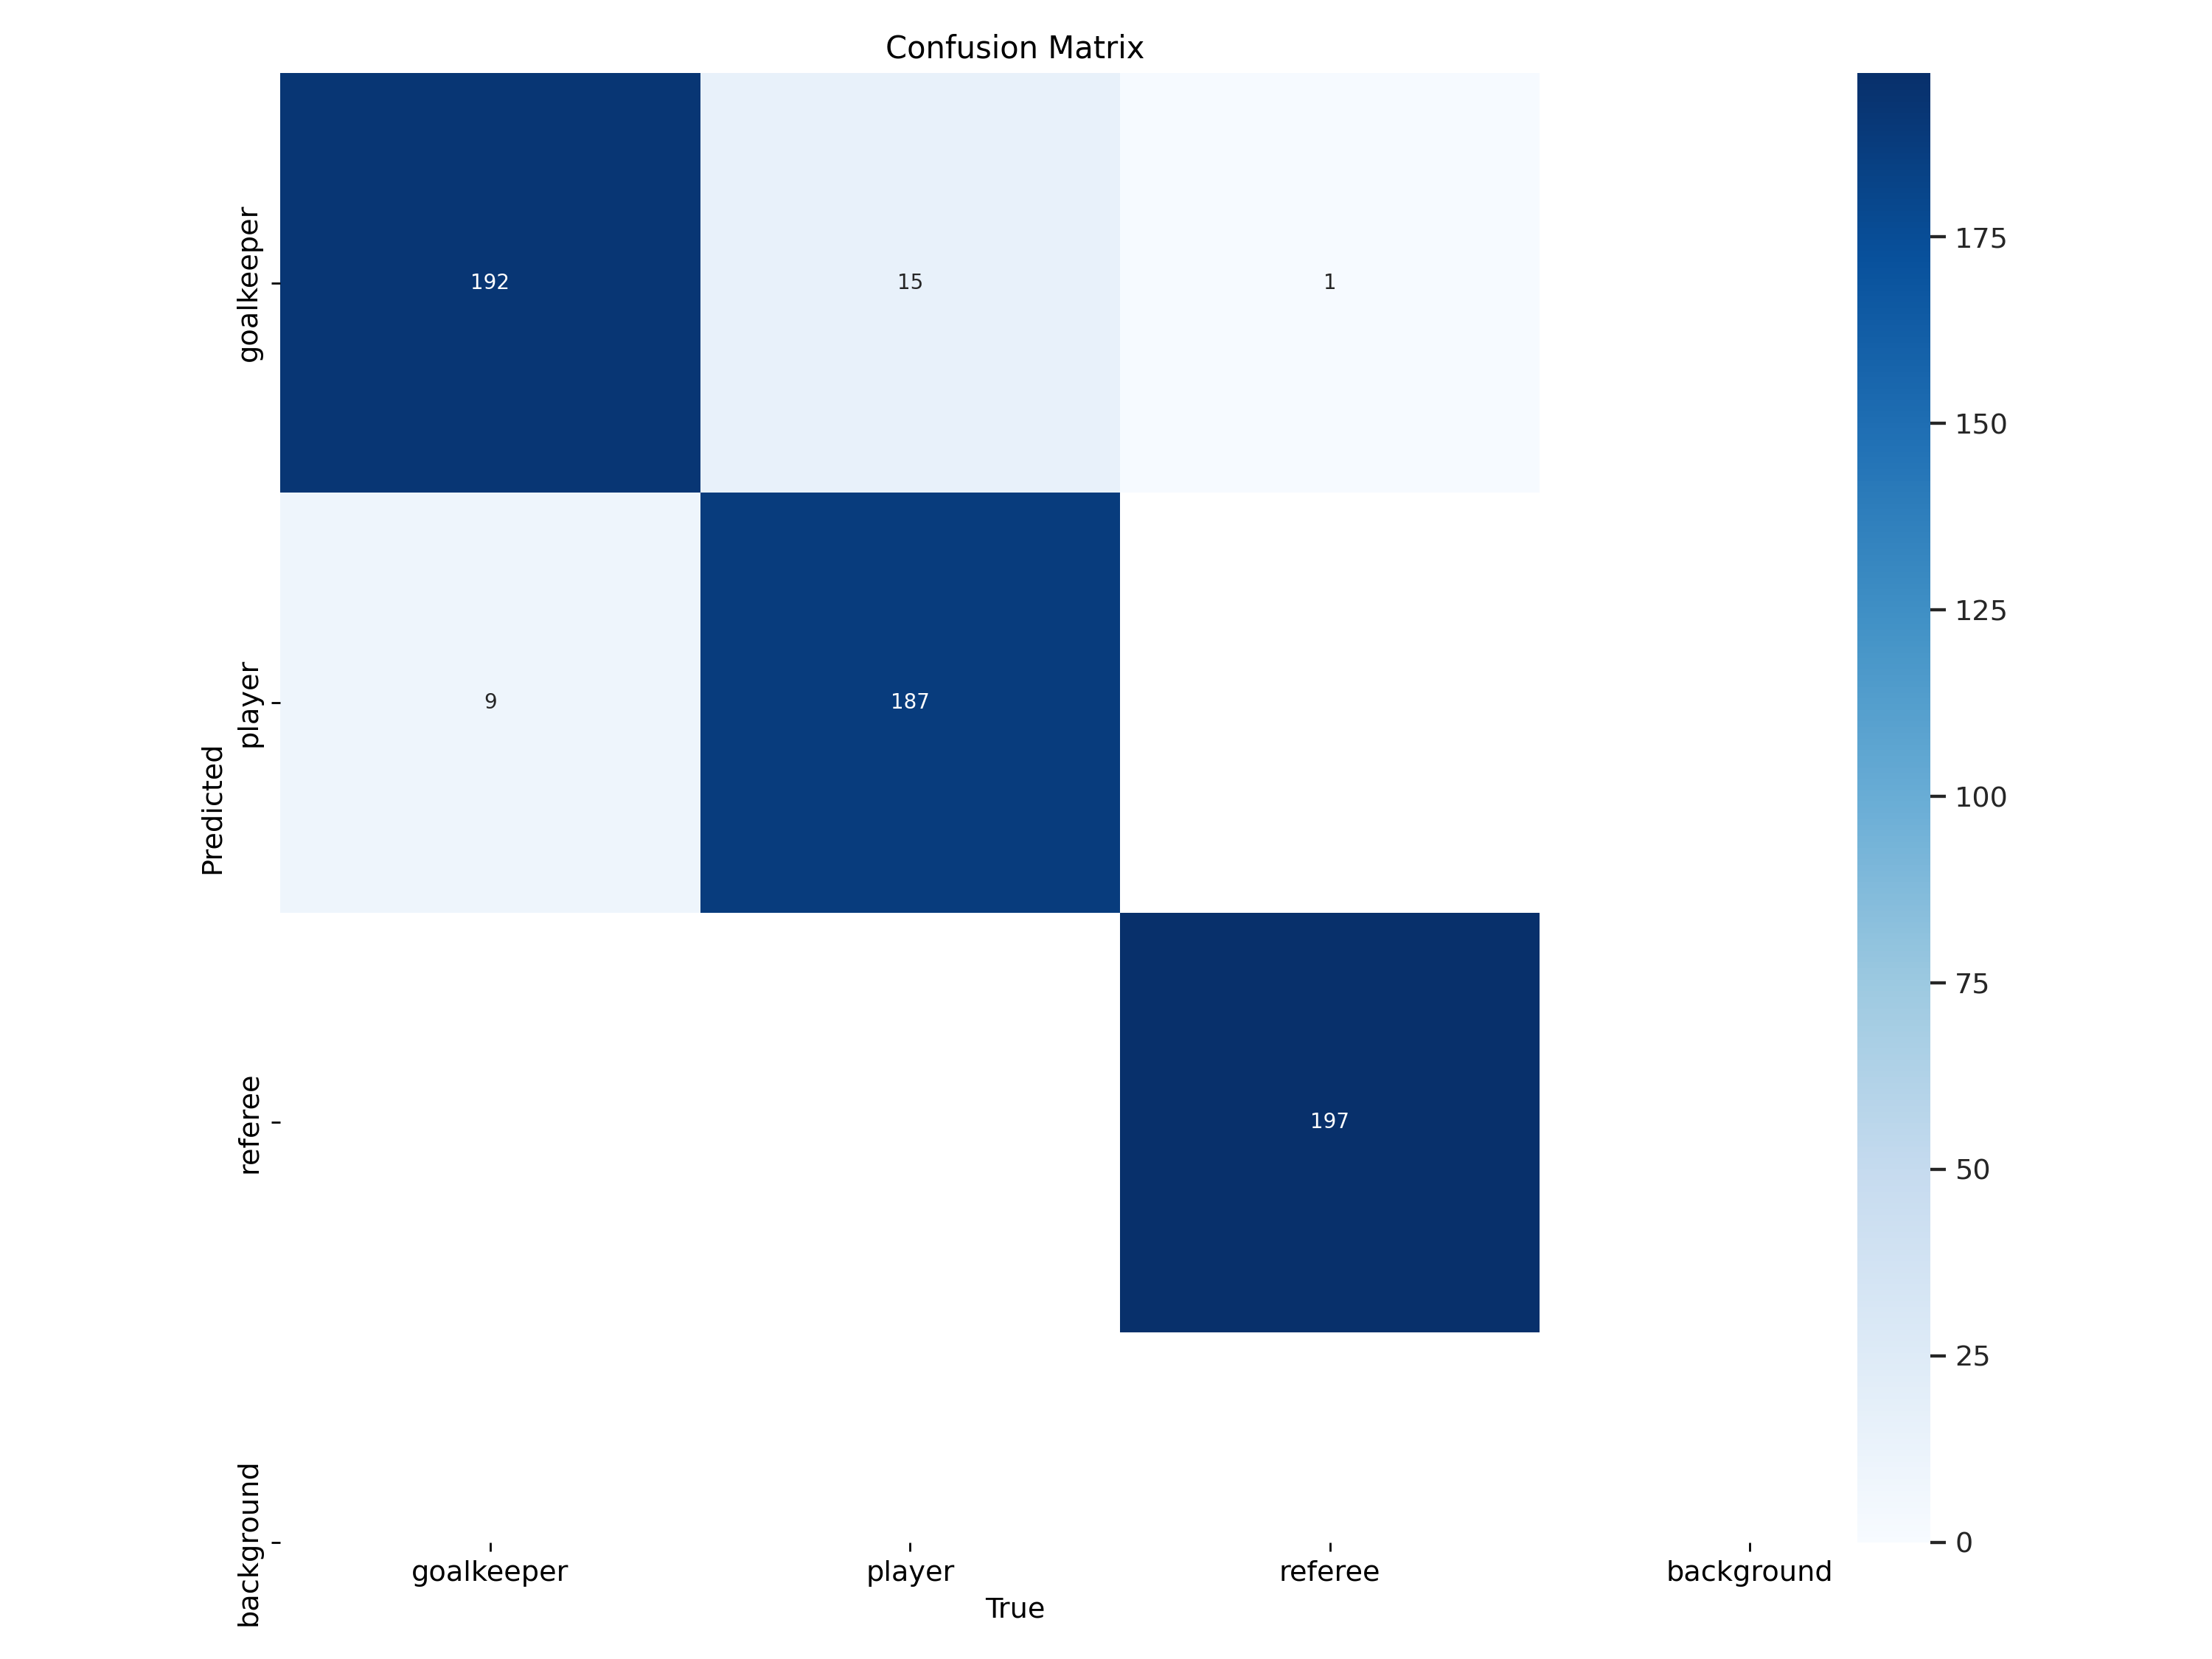

In [105]:
%cd {HOME}
# Ma trận nhầm lẫn
Image(filename=f'{HOME}/runs/classify/val/confusion_matrix.png', width=800)

### Inference with Custom Model

Chạy mô hình YOLOv8 đã huấn luyện để dự đoán trên tập test (ảnh chưa có nhãn) và lưu ảnh kết quả.

In [106]:
import shutil
shutil.rmtree(f'{HOME}/runs/classify/predict', ignore_errors=True)

# Đường dẫn mô hình đã huấn luyện và thư mục ảnh test
model_path = f"{HOME}/runs/classify/train/weights/best.pt"
source_path = f"{HOME}/dataset/pred/player"

# Load mô hình YOLOv8
model = YOLO(model_path)

# Dự đoán ảnh trong folder test
results = model.predict(
    source=source_path,     # thư mục chứa ảnh test
    conf=0.5,              # ngưỡng confidence
    save=True,              # lưu ảnh dự đoán
    name="predict",         # tên thư mục output
    exist_ok=True           # ghi đè nếu thư mục đã tồn tại
)


image 1/15 /kaggle/working/dataset/pred/player/21.HAGLVHN7_f0033_p00.jpg: 224x224 player 1.00, goalkeeper 0.00, referee 0.00, 3.5ms
image 2/15 /kaggle/working/dataset/pred/player/21.HAGLVHN7_f0111_p04.jpg: 224x224 player 0.95, goalkeeper 0.05, referee 0.00, 3.2ms
image 3/15 /kaggle/working/dataset/pred/player/21.HAGLVHN7_f0194_p00.jpg: 224x224 player 0.98, goalkeeper 0.02, referee 0.00, 2.9ms
image 4/15 /kaggle/working/dataset/pred/player/21.HAGLVHN7_f0291_p00.jpg: 224x224 player 0.78, goalkeeper 0.22, referee 0.00, 2.8ms
image 5/15 /kaggle/working/dataset/pred/player/21.HAGLVHN7_f0291_p01.jpg: 224x224 player 0.87, goalkeeper 0.13, referee 0.00, 2.8ms
image 6/15 /kaggle/working/dataset/pred/player/21.HAGLVHN7_f0360_p00.jpg: 224x224 player 0.54, goalkeeper 0.46, referee 0.00, 2.9ms
image 7/15 /kaggle/working/dataset/pred/player/21.HAGLVHN7_f0544_p00.jpg: 224x224 player 1.00, goalkeeper 0.00, referee 0.00, 2.8ms
image 8/15 /kaggle/working/dataset/pred/player/21.HAGLVHN7_f0546_p00.jpg: 2

In [107]:
# Hiển thị cấu trúc thư mục predict sau khi inference xong
!ls {HOME}/runs/classify/predict

21.HAGLVHN7_f0033_p00.jpg  21.HAGLVHN7_f0360_p00.jpg  21.HAGLVHN7_f0867_p01.jpg
21.HAGLVHN7_f0111_p04.jpg  21.HAGLVHN7_f0544_p00.jpg  21.HAGLVHN7_f0868_p01.jpg
21.HAGLVHN7_f0194_p00.jpg  21.HAGLVHN7_f0546_p00.jpg  21.HAGLVHN7_f0880_p00.jpg
21.HAGLVHN7_f0291_p00.jpg  21.HAGLVHN7_f0838_p00.jpg  21.HAGLVHN7_f0890_p00.jpg
21.HAGLVHN7_f0291_p01.jpg  21.HAGLVHN7_f0839_p00.jpg  21.HAGLVHN7_f0890_p01.jpg


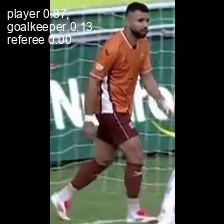

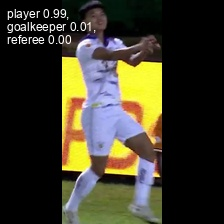

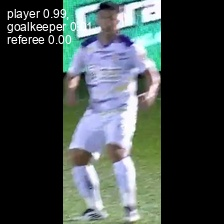

In [108]:
import glob
from IPython.display import Image, display

# Define the base path where the folders are located
base_path = f'{HOME}/runs/classify/'

# List all directories that start with 'predict' in the base path
subfolders = [os.path.join(base_path, d) for d in os.listdir(base_path)
              if os.path.isdir(os.path.join(base_path, d)) and d.startswith('predict')]

# Find the latest folder by modification time
# Lấy tối đa 3 ảnh .jpg đầu tiên trong thư mục predict mới nhất.
latest_folder = max(subfolders, key=os.path.getmtime)

image_paths = glob.glob(f'{latest_folder}/*.jpg')[:3]

# Display each image
for image_path in image_paths:
    display(Image(filename=image_path, width=200))
    #print("\n")

### Chạy YOLOv8-cls trực tiếp trên video

Kết hợp YOLOv8 (detect) + YOLOv8n-cls (classify).

Từ một video đầu vào:
- YOLOv8 (detect) phát hiện người (class 0).
- YOLOv8n-cls (mô hình bạn huấn luyện) phân loại người đó là: referee, player, goalkeeper.

✅ Kết quả là video có khung bbox và nhãn phân lớp hiển thị rõ ràng.

Pipeline:
- yolov8n.pt phát hiện person (COCO class 0).
- Mỗi person → crop → resize → đưa qua mô hình YOLOv8n-cls.
- Nhãn + xác suất phân lớp sẽ được vẽ lên từng khung hình.
- Kết quả cuối là video có bbox + nhãn player/referee/goalkeeper.

In [109]:
import cv2
import os
import numpy as np
from ultralytics import YOLO

# Đường dẫn
#video_path = "/kaggle/input/football-sample-videos/football_2932301.mp4"
#output_video_path = f"{HOME}/runs/classify/predict_video/football_2932301_labeled.avi"
video_path = "/kaggle/input/football-sample-videos/92.Hai-Phong-vs-The-Cong-Viettel_h264_short.mp4"
output_video_path = f"{HOME}/runs/classify/predict_video/92.Hai-Phong-vs-The-Cong-Viettel_h264_short.avi"

# Tạo thư mục output nếu chưa có
os.makedirs(os.path.dirname(output_video_path), exist_ok=True)

temp_frame_dir = "temp_frames"
os.makedirs(temp_frame_dir, exist_ok=True)

# Load models
detector = YOLO("yolov8n.pt")  # YOLOv8 object detector (COCO pretrained)
classifier = YOLO(f"{HOME}/runs/classify/train/weights/best.pt")  # YOLOv8n-cls của bạn

# Video reader/writer
cap = cv2.VideoCapture(video_path)
fps = cap.get(cv2.CAP_PROP_FPS)
width, height = int(cap.get(3)), int(cap.get(4))
out = cv2.VideoWriter(output_video_path, cv2.VideoWriter_fourcc(*'XVID'), fps, (width, height))

frame_id = 0

while True:
    ret, frame = cap.read()
    if not ret:
        break

    # Detect người
    results = detector(frame, verbose=False)[0]
    for box in results.boxes:
        cls_id = int(box.cls)
        if cls_id != 0:  # chỉ phát hiện người
            continue

        x1, y1, x2, y2 = map(int, box.xyxy[0])
        person_crop = frame[y1:y2, x1:x2]
        try:
            person_resized = cv2.resize(person_crop, (224, 224))
        except:
            continue  # bỏ qua nếu crop lỗi

        # Classify
        pred = classifier(person_resized, verbose=False)[0]
        label = pred.names[int(pred.probs.top1)]
        conf = float(pred.probs.top1conf)

        # Vẽ lên frame
        cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 255, 0), 2)
        text = f"{label} ({conf:.2f})"
        cv2.putText(frame, text, (x1, y1 - 8), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 0, 0), 2)

    out.write(frame)
    frame_id += 1

cap.release()
out.release()
print("Video đã được xử lý và lưu tại:", output_video_path)

Video đã được xử lý và lưu tại: /kaggle/working/runs/classify/predict_video/92.Hai-Phong-vs-The-Cong-Viettel_h264_short.avi


In [110]:
# Hiển thị cấu trúc thư mục sau khi chạy YOLO trực tiếp trên video xong
!ls {HOME}/runs/classify/predict_video

92.Hai-Phong-vs-The-Cong-Viettel_h264_short.avi


<h2 style="background-color: #367E7F; color: white; padding: 15px; text-align: center; font-size: 20px; border-radius: 6px; font-weight: bold;">
    7.6 Accuracy and Loss Comparision
</h2>

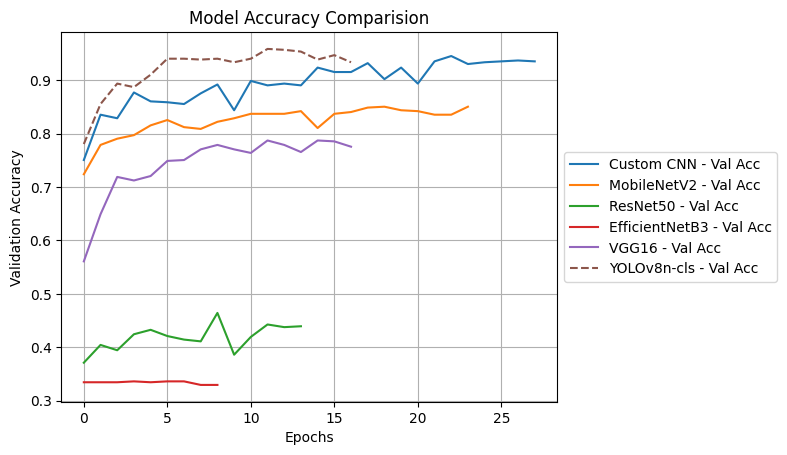

In [111]:
# Accuracy comparison
plt.plot(history.history['val_accuracy'], label='Custom CNN - Val Acc')
plt.plot(history_PretrainedMobileNetV2.history['val_accuracy'], label='MobileNetV2 - Val Acc')
plt.plot(history_PretrainedResNet50.history['val_accuracy'], label='ResNet50 - Val Acc')
plt.plot(history_EfficientNetB3.history['val_accuracy'], label='EfficientNetB3 - Val Acc')
plt.plot(history_PretrainedVGG16.history['val_accuracy'], label='VGG16 - Val Acc')
plt.plot(yolo_val_accuracy, label='YOLOv8n-cls - Val Acc', linestyle='--')
plt.xlabel('Epochs')
plt.ylabel('Validation Accuracy')
plt.title('Model Accuracy Comparision')
#plt.legend(loc='lower right')  # Legend ở góc dưới bên phải
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))  # Đặt legend bên phải, bên ngoài biểu đồ
#plt.tight_layout()  # Giúp tự động căn lề cho gọn
plt.grid(True)
plt.show()

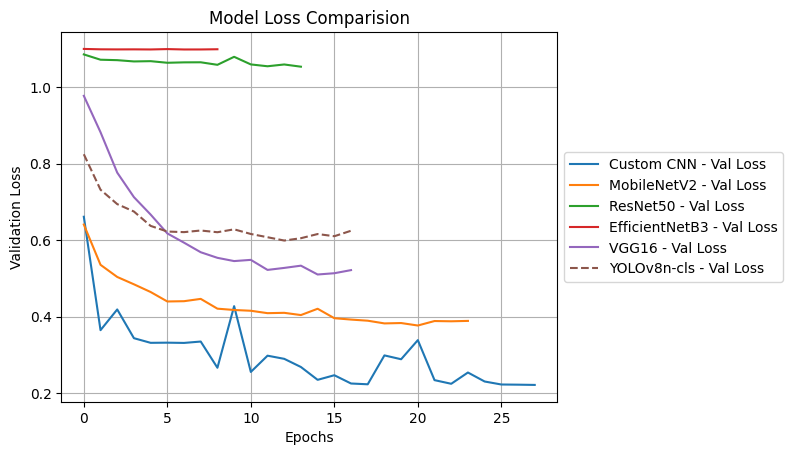

In [112]:
# Loss comparison
plt.plot(history.history['val_loss'], label='Custom CNN - Val Loss')
plt.plot(history_PretrainedMobileNetV2.history['val_loss'], label='MobileNetV2 - Val Loss')
plt.plot(history_PretrainedResNet50.history['val_loss'], label='ResNet50 - Val Loss')
plt.plot(history_EfficientNetB3.history['val_loss'], label='EfficientNetB3 - Val Loss')
plt.plot(history_PretrainedVGG16.history['val_loss'], label='VGG16 - Val Loss')
plt.plot(yolo_val_loss, label='YOLOv8n-cls - Val Loss', linestyle='--')
plt.xlabel('Epochs')
plt.ylabel('Validation Loss')
plt.title('Model Loss Comparision')
#plt.legend(loc='lower right')  # Legend ở góc dưới bên phải
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))  # Đặt legend bên phải, bên ngoài biểu đồ
plt.grid(True)
plt.show()

<h2 style="background-color: #367E7F; color: white; padding: 15px; text-align: center; font-size: 20px; border-radius: 6px; font-weight: bold;">
    8. Conclusion
</h2>



<div style=" color: #595959; padding: 15px; font-size: 16px; border: 1px solid #367E7F; border-radius: 6px">                
Our experiments demonstrate the power of transfer learning in image classification. While our custom CNN achieved 86% accuracy, leveraging pretrained models significantly improved performance. EfficientNetB3 achieved the highest accuracy at 93%, followed by VGG16 with 90%.<br>
These results highlight the efficiency of pretrained models in extracting meaningful features, reducing training time, and improving accuracy. In future work, fine-tuning these models, experimenting with other architectures, or applying advanced techniques like data augmentation and hyperparameter optimization could further enhance performance.<br>
</div>
